# Data Cleaning and EDA
ノイズの多いデータセットを、まずは**データクリーニングとEDA**する

- サンプル事例の背景
  - あるカフェチェーン。都心近郊に10店舗を展開、1万人規模の自社アプリ会員を持つ。
  - アプリ会員はお店での注文時は必ずアプリを提示する。来店せずともアプリを閲覧することはある。
  - だがこれらのデータは現状は有効に活用されていない。
- 問題の設定
  - **誰がラテを購入するかを予測**する（来店した顧客が、ラテを購入する確率、可能性を数値化する）。
  - 結果をどう使うかは詳細未定。まずは、予測が可能なのか、どの程度の精度が出るのを見極めるという初期段階。
  - 施策案: 店頭やアプリでの情報表示などをパーソナライズ、ラテを購入しやすい顧客層の分析、新商品企画やCRMのための顧客理解など。
- 本コードの位置付け
  - データセットは受け取ったものの、詳細が不明、あるいはドメイン知識が乏しい。
  - そこで、**データをざっと眺めて、最低限のクリーニングやデータ概況把握する**ことで、手早くモデリング準備を整えることを意図している。
  - まずはLightGBMでモデリングする予定（なのでNaNはNaNのままにする前提）。

In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# import scipy
import sklearn

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas",
"numpy",
"matplotlib",
"seaborn",
"scikit-learn",
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-09-11 16:38:44
Python 3.11.15
OS macOS-26.6.2-arm64-arm-64bit
is_google_colab: False
pandas 3.0.2
numpy 2.4.3
matplotlib 3.10.9
seaborn 0.13.2
scikit-learn 1.8.0


In [2]:
# サンプルデータの生成（意図的にデータ汚損している）
import string

def generate_cafe_raw_data(n_customers=10000, n_stores=10, seed=42):
    """
    顧客単位×日次のTransaction（アプリのPVや来店）に、顧客マスターや店舗マスターをLeft Joinして生成するイメージ
    - 配下10店舗それぞれの過去3ヶ月の、顧客別ラテ注文有無実績+関連データ
    - 予測には役立ちそうもない特徴量も含まれている
    """
    np.random.seed(seed)
    
    # 共通の期間設定 (計91日間)
    start_date = pd.Timestamp('2025-09-01')
    end_date = pd.Timestamp('2025-11-30')
    date_range = pd.date_range(start_date, end_date)
    holidays = [pd.Timestamp(h) for h in ['2025-09-15', '2025-09-23', '2025-10-13', '2025-11-03', '2025-11-23', '2025-11-24']]  # 祝日リスト
    
    # IDなどの基本パーツ
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    chars = list(string.ascii_lowercase + string.digits)
    customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
    # =================================================================
    # テーブル1: 【顧客マスター (dim_customers)】
    # =================================================================
    # 顧客マスタ（入会日 signup_date を過去3年の範囲でランダム生成）
    # 今回ログの最終日から最大1000日前までの間で入会日を決める
    # これにより、この3ヶ月の期間中に新規入会する（生まれる）顧客も自然にシミュレートできる
    random_days_ago = np.random.randint(0, 1000, n_customers)
    # 入会からの経過日数（tenure）が長い人ほど、飽きてアプリを開かない確率（デバフ）を作る
    # 新規入会者はアクティブ（確率高）、1年以上前の人は幽霊部員になりやすい構造にする

    # 基本のアプリ大好き度
    app_engagement_base = np.random.beta(5, 2, n_customers)
    # 入会からの日数による減衰（半年〜1年でガクッと落ちる）
    tenure_decay = np.exp(-random_days_ago / 365)
    # 最低でも2%は開く
    app_open_prob = (app_engagement_base * tenure_decay).clip(0.02, 1.0)
    
    base_visit_freq_smooth = np.random.gamma(shape=3.0, scale=1.0, size=n_customers).clip(0.5, 15.0)
    
    # ユーザー単位で「金の卵」となるユーザーを定義
    # 入会1年未満（365日未満）のライトユーザーから、ランダムに10%を抽出
    is_light_user = random_days_ago < 365
    is_gold_egg_user = is_light_user & (np.random.rand(n_customers) < 0.10)
    
    df_customers_master = pd.DataFrame({
        'customer_id': customer_ids,
        'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
        'main_store_id': np.random.choice(store_ids, n_customers),  # その人のマイ店舗
        'base_latte_preference': np.random.beta(1.5, 5, n_customers),
        'base_visit_freq': base_visit_freq_smooth, 
        'app_open_prob': app_open_prob,
        'is_gold_egg': is_gold_egg_user.astype(int)  # 内部フラグとしてマスタに追加
    })
    
    # =================================================================
    # テーブル2: 【店舗×日付マスター】 1店舗×1日1行
    # =================================================================
    store_date_records = []
    for s in store_ids:
        for d in date_range:
            store_date_records.append({
                'store_id': s,
                'date': d,
                'is_raining': np.random.binomial(1, 0.2),  # 確率20%で雨
                'station_congestion_index': np.random.normal(100, 15),
                'daily_staffing_cost': int(np.random.randint(50000, 150000))
            })
    df_store_master = pd.DataFrame(store_date_records)
    store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}  # 店舗バイアス
    
    # =================================================================
    # テーブル3: 【日次アプリログ（ベースデータフレーム）】
    # =================================================================
    df_date_base = pd.DataFrame({'date': date_range})
    df_date_base['is_weekend'] = df_date_base['date'].dt.dayofweek.isin([5, 6]).astype(int)
    df_date_base['is_holiday'] = df_date_base['date'].isin(holidays).astype(int)
    df_date_base['is_day_off'] = ((df_date_base['is_weekend'] == 1) | (df_date_base['is_holiday'] == 1)).astype(int)
    
    # 自然な連続値としての気温を作る
    # 9月、10月、11月のベースを滑らかに繋ぎつつ、前日の気温をベースにランダムウォークさせるにゃん
    temps = []
    current_t = 24.0 # 初期値（9月1日の気温ベース）
    for d in date_range:
        # 月ごとの目標となる平均気温
        target_m = 24.0 if d.month == 9 else (17.0 if d.month == 10 else 12.0)
        # 前日の気温を引きずりつつ、今月の目標気温に少し引っ張られつつ、ランダムに変動（±1度程度）
        current_t = current_t * 0.8 + target_m * 0.2 + np.random.normal(0, 1.2)
        temps.append(current_t)
        
    df_date_base['current_temp'] = temps
    
    # クロスジョインで全顧客×全日付のログ枠を生成
    df_cust_stub = pd.DataFrame({'customer_id': customer_ids})
    df_cust_stub['key'], df_date_base['key'] = 1, 1
    df_transaction = pd.merge(df_cust_stub, df_date_base, on='key').drop('key', axis=1)
    
    # STEP1: トランザクションに顧客マスターをLeft Join（SQLのイメージ）
    df_log = pd.merge(df_transaction, df_customers_master, on='customer_id', how='left')
    
    # 入会前のレコードをカット＆会員日数の計算
    df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
    df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
    # 現実化フィルター
    # 各ユーザー×各日付に対してサイコロを振り、その日の起動確率を下回った日は「行ごと消滅」させる
    # ただし、当日お店に行く日（後述のvisit_logitが上振れる日）のログが消えるとバグるので、
    # お店に行く、またはアプリを自主的に開いた日だけを生存させるロジックにする
    visit_logit_temp = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_prob_temp = 1 / (1 + np.exp(-visit_logit_temp))
    
    # お店に行く確率かアプリを開く確率のどちらかで生存判定
    survival_prob = np.maximum(visit_prob_temp, df_log['app_open_prob'])
    df_log = df_log[np.random.rand(len(df_log)) < survival_prob].reset_index(drop=True)
    
    # フラグ決定フェーズ（行が間引かれた状態で実行される）
    # STEP2: 確率計算をして、日々の行動フラグ（来店・PV・購買）を決定
    # (※確率計算のために、一時的にその日の雨フラグだけ裏で店舗マスタから貰ってくる)
    df_log = pd.merge(df_log, df_store_master[['store_id', 'date', 'is_raining']], 
                      left_on=['main_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('store_id', axis=1)
    
    # 顧客マスタから引き継いだフラグをそのままマスクとして使用
    gold_egg_mask = df_log['is_gold_egg'] == 1
    
    # ① 来店フラグ (is_visited)
    visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
    df_log['is_visited'] = np.random.binomial(1, 1 / (1 + np.exp(-visit_logit)))
    
    # ② アプリPV数 (app_pv)
    # お店に行かない日は、PV数が0や1の日が大量に発生するようにポアソン分布を調整
    base_pv = np.random.poisson(0.5, len(df_log)) + df_log['is_visited'] * 4
    df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(3, len(df_log)), base_pv)
    # 最低でもアプリの起動ログがある以上、1PVは発生させる
    df_log['app_pv'] = df_log['app_pv'].clip(lower=1)
    
    # ③ ラテ購入フラグ (is_purchased)※条件付き確率
    # 雨の日は確率が下がる
    store_bias = df_log['main_store_id'].map(store_effect)
    purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
    purchase_logit = np.where(df_log['is_raining'] == 1, purchase_logit - 1.5, purchase_logit)
    purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
    df_log['is_purchased'] = np.random.binomial(1, 1 / (1 + np.exp(-purchase_logit))) * df_log['is_visited']
    
    # 内部用の不要カラムを落とす
    # 一時的に使った雨フラグと、不要になった顧客マスタの感度用内部カラム（金の卵フラグ含む）を落とす
    df_log = df_log.drop(['is_raining', 'base_latte_preference', 'base_visit_freq', 'app_open_prob', 'is_gold_egg'], axis=1)
    
    # STEP3: 来店キーの作成
    # 来店してない日は NaN になるので、店舗マスタと結合できずにNull出力になる仕組み
    df_log['join_store_id'] = np.where(df_log['is_visited'] == 1, df_log['main_store_id'], np.nan)
    df_log = df_log.drop('main_store_id', axis=1)  # マイ店舗の漏洩を防ぐ
    
    # STEP4: トランザクションに店舗×日付マスターをLeft Join
    df_final = pd.merge(df_log, df_store_master, left_on=['join_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('join_store_id', axis=1)
    
    # カラムの並び順を整理
    df_dirty = df_final[[
        'date', 'customer_id', 'membership_days', 'app_pv', 'store_id', 'is_visited', 'is_purchased',  'current_temp', 'is_raining', 'station_congestion_index', 'daily_staffing_cost']]
        
    # 意図的にデータ汚損
    df_dirty = df_dirty.copy()
    # わざと欠損値を含める
    df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    # わざとobject型にする
    df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
    # わざと?を混入させる
    df_dirty.loc[df_dirty.sample(frac=0.005).index, 'membership_days'] = '?'
    # 空文字トラップ
    df_dirty.loc[df_dirty.sample(frac=0.003).index, 'membership_days'] = ''
    df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
    # アプリPV（app_pv）の1%をNaNにする
    df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
    # 店舗ID（store_id）の一部（0.5%）を小文字混じりにする
    valid_store_idx = df_dirty[df_dirty['store_id'].notnull()].sample(frac=0.005).index
    df_dirty.loc[valid_store_idx, 'store_id'] = df_dirty.loc[valid_store_idx, 'store_id'].str.lower()
    
    # 時系列のシャッフル（未ソートで出力）
    df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)

    print(f"データセット生成完了！ 総行数: {len(df_dirty)}行")
    return df_dirty

# 実行
df1 = generate_cafe_raw_data()

データセット生成完了！ 総行数: 226445行


## 前提シナリオ
- 分析者は前述の分析テーマは知っているが、サンプルデータの生成ロジックは知らない
- データセットを受け取り、カラム内容については以下情報を得た
- だが各カラムの意味や構造については詳しくないし、わかる人がしばらくは近くにいない
- そのため自力でデータを眺めてデータセットを理解するところから始まる
- データ量は多くはないのでエクセルに読み込んで眺めてもよいがここではPythonで完結する体裁で進める

データセットの内容（カラムの説明）
- date ログデータ発生日
- customer_id 顧客ID
- membership_days アプリ会員になってからの経過日数
- app_pv アプリ閲覧数
- store_id 店舗ID
- is_visited 来店有無
- is_purchased ラテ購入有無
- current_temp その日の気温
- is_raining 降雨フラグ
- station_congestion_index 店舗の最寄駅の混雑指数
- daily_staffing_cost その日のそのお店のパート、バイト人件費総額

# Speedy Check
- データセットの中身、行列数、データ型は意図通りか、混入物がないか確認
- データの不完全さを素早く直感的に把握し、データのクリーニング方法などを適切に判断する
- この段階ではデータをキレイにするところがゴール
- Null（NaN）をどう扱うかは後回し

In [3]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

# カラム名と中身が違ってそうな場合、そのデータセットは本来のものなのか、単にカラム名が違ってただけなのか、列がズレてるのかなどを疑う必要あり
# dateの並び順がソートされてなさそうなこと、一部のカラムでnullがあることがわかる

        date customer_id membership_days  app_pv store_id  is_visited  \
0 2025-10-25    zr9fk3nj             867     1.0      NaN           0   
1 2025-10-07    4zck20j8             426     5.0  Store_D           1   
2 2025-09-08    bu6lvy01              27     1.0      NaN           0   
3 2025-09-13    e6x7yyve              14     1.0      NaN           0   
4 2025-11-05    y8abopw8              15     1.0      NaN           0   

   is_purchased  current_temp  is_raining  station_congestion_index  \
0             0     15.792930         NaN                       NaN   
1             0     18.477874         0.0                 81.960862   
2             0     23.322725         NaN                       NaN   
3             0     23.180668         NaN                       NaN   
4             0     13.955347         NaN                       NaN   

   daily_staffing_cost  
0                  NaN  
1             121841.0  
2                  NaN  
3                  NaN  
4        

In [4]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
# 期待してるデータ型になってそうか？nullがありそうか？（次のdescribeでも把握可能）
print(df1.info())

(226445, 11)
<class 'pandas.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   date                      226445 non-null  datetime64[us]
 1   customer_id               226445 non-null  str           
 2   membership_days           226445 non-null  object        
 3   app_pv                    224181 non-null  float64       
 4   store_id                  38307 non-null   str           
 5   is_visited                226445 non-null  int64         
 6   is_purchased              226445 non-null  int64         
 7   current_temp              219652 non-null  float64       
 8   is_raining                38307 non-null   float64       
 9   station_congestion_index  38307 non-null   float64       
 10  daily_staffing_cost       38307 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2), object(1), str(2)
m

In [5]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 数値型カラムの要約統計量
df1.describe(include='number').round(2)

# is_visited, is_purchased, is_rainingは2値っぽい
# 2値っぽくない他のカラムについてはこれだけではよくわからない（極端な外れ値は含まれてるのかもだし、妥当な範囲かもしれない）
# とはいえ4カラムのうち、app_pvはmin=1（min=0ではない）。残り3カラムも同様にmin=0ではないが、名称からして妥当にも思える。
# であれば、app_pvのmin=0ではない、そしてis_visitedやis_purchasedはmin=0であるからして、このデータセットは（来店や購入せずとも）app_pvが発生したときに行が存在するようなデータ構造になっていそうに思える。

,app_pv,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost
count,224181.00,226445.00,226445.00,219652.00,38307.0,38307.00,38307.00
mean,1.87,0.17,0.05,17.85,0.2,101.35,98874.56
std,2.09,0.37,0.22,4.31,0.4,15.29,28314.08
min,1.00,0.00,0.00,8.26,0.0,41.81,50181.00
25%,1.00,0.00,0.00,13.97,0.0,91.03,74292.00
50%,1.00,0.00,0.00,18.43,0.0,101.32,98798.00
75%,2.00,0.00,0.00,21.40,0.0,111.53,122543.00
max,31.00,1.00,1.00,25.50,1.0,154.92,149992.00


In [6]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 非数値型カラムの要約統計量（datetime型なら期間の範囲、文字列ならばユニーク値や頻出値かなど）
df1.describe(exclude='number')

# dateカラムはdatetime型になってる。範囲はわかる（でも毎日分あるかは不明）
# customer_idやstore_idは文字列扱いなので情報少ない（ユニーク値や頻出値が妥当なのかはよくわからない）
# membership_daysはカラム名からすると数値型っぽいがそうなってない、数値以外のデータが混じってるらしいことがわかる

,date,customer_id,membership_days,store_id
count,226445,226445,226445,38307
unique,NaN,9994,1002,20
top,NaN,eqh7iw8g,?,Store_J
freq,NaN,75,1129,4136
mean,2025-10-17 19:48:40.778113,NaN,NaN,NaN
min,2025-09-01 00:00:00,NaN,NaN,NaN
25%,2025-09-25 00:00:00,NaN,NaN,NaN
50%,2025-10-19 00:00:00,NaN,NaN,NaN
75%,2025-11-09 00:00:00,NaN,NaN,NaN
max,2025-11-30 00:00:00,NaN,NaN,NaN


数値型っぽいカラムに、数値以外のデータが混じってるらしい場合の対処法

1. 主要な機械学習ライブラリでは、NaNがあっても対処可能
1. だが、NaNではない欠損値（例えば空文字や不正な値）が混じっている場合はモデル作成時にエラーとなる
1. よって手軽に素早くモデル作成したい場合は、ひとまず欠損値をNaNにしてしまう
1. NaNを補完（例えば平均値や中央値で埋めるなど）するかどうかは別として、とりあえずNaNにしておけば先に進める

問題のmembership_daysカラムの対処は、後続のdata cleaningの、dtypes exclude numberにておこなう


一方で、以下の場合はさほど致命的な事態は招きにくい
- 本来はカテゴリ変数や文字列として扱いたいカラムが、数値型扱いになっている
- カテゴリ変数や文字列として扱いたいカラムに、表記揺れ、空白、全角半角の違いなどが混じっている

これらはモデル性能の低下は招くが、素早くモデルを作成したり、アルゴリズムの選定においては最優先事項でもない

## sort
データを並べ替えて眺めてみる

In [7]:
# 事前情報（カラム説明）とここまでの工程からして、日次単位のデータであること、識別子としてcustomer_idとstore_idがあること、時点順や識別子順でソートされてはなさそうなことはわかった
# だがカラム間の関係性や、データセットの最小単位はまだつかみかねている

# 識別子であるcustomer_id, store_idと、時点データであるdateの計3つでソートしてみる
df1.sort_values(by=['customer_id', 'date', 'store_id']).reset_index(drop=True).head(10)

# 顧客、日付、お店順で眺めると、同じ人が複数日で登場する、そして毎日連続したデータが並ぶわけでははなさそうとわかる

# store_idなどnullが多いカラムは、どういうときにnullになるのかが人間の目でも規則性が見えそう
# 以下の場合、store_idがnullだとis_raining, station_congestion_index, daily_staffing_costもnullになっている。そしてis_visited, is_purchasedは0になっているように思える。nullのカラムはひょっとするとstore_idに関連する情報なのかもしれない。来店や購入してない場合はstore_id関連情報がnullになるのかもしれない

# ここまでの情報からすると、app_pvが発生した日のみでのtransactionログをベースに、来店や購入したときにはお店関連のmaster情報を突合したようなデータ構造なのかもしれない。
# 顧客関連のmaster情報はmembership_daysのみで、これはdateに応じてカウントアップした値が突合されているのかもしれない。
# current_tempがどのdateでも格納されているのはよくわからない。各店舗の所在エリアの、そのdateの気温なのかもしれない。

,date,customer_id,membership_days,app_pv,store_id,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost
0,2025-09-01,002ec2m6,279,1.0,NaN,0,0,24.804228,NaN,NaN,NaN
1,2025-09-05,002ec2m6,283,1.0,NaN,0,0,22.264802,NaN,NaN,NaN
2,2025-09-09,002ec2m6,287,4.0,Store_I,1,1,22.034767,0.0,80.767376,128455.0
3,2025-09-18,002ec2m6,296,NaN,NaN,0,0,22.869419,NaN,NaN,NaN
4,2025-09-22,002ec2m6,300,1.0,NaN,0,0,25.498009,NaN,NaN,NaN
5,2025-09-30,002ec2m6,308,1.0,NaN,0,0,21.384111,NaN,NaN,NaN
6,2025-10-13,002ec2m6,321,1.0,NaN,0,0,19.441402,NaN,NaN,NaN
7,2025-10-16,002ec2m6,324,1.0,NaN,0,0,20.423096,NaN,NaN,NaN
8,2025-10-17,002ec2m6,325,1.0,NaN,0,0,19.642861,NaN,NaN,NaN
9,2025-10-18,002ec2m6,326,1.0,NaN,0,0,18.845977,NaN,NaN,NaN


## granularity
データの最小単位を探索する granularity（粒度）

In [8]:
# 識別子であるcustomer_id, store_idと、時点データであるdateの計3つで集約して、その行数（size）を数える
# 最大の行数が1を超えているなら、この集約単位が最小単位とはいえない
# 最大の行数が1なら、この集約単位が最小単位かもだし、さらに減らした状態が最小単位かもしれない

# nullも1つのグループとして扱えるように引数指定する（groupbyでの指定カラムにnullがあっても無視しないようにする）
max_duplicate_count = df1.groupby(['customer_id', 'store_id', 'date'], dropna=False).size().max()

print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

# 同じ顧客が同じ日に同じ店で複数のログが発生することはなさそうとわかる

現状集約単位での最大行数: 1
✨ この組み合わせは最小単位かもにゃん!


In [9]:
# customer_id, store_id,dateでソートした結果から、この組み合わせが最小単位とは思えないが念のため

max_duplicate_count = df1.groupby(['customer_id', 'store_id']).size().max()
print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

現状集約単位での最大行数: 28
🚨 この組み合わせは最小単位ではなさそうにゃん!


## duplicate
重複してる行は何なのかをみてみる

In [10]:
df_duplicates = df1[df1.duplicated(subset=['customer_id', 'store_id'], keep=False)]
# subsetの中にnullが含まれていても、null同士を同じものとして重複検知してくれる（nullを無視することはない）

print(f"🚨 重複している行数: {len(df_duplicates)} 行")  # 重複しているデータの件数を確認
df_duplicates.sort_values(by=['customer_id', 'store_id']).head(10)  # ソートして目視確認

# 同じ顧客が同じお店で期間内に複数のログが発生することはある

🚨 重複している行数: 224751 行


,date,customer_id,membership_days,app_pv,store_id,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost
43415,2025-09-09,002ec2m6,287,4.0,Store_I,1,1,22.034767,0.0,80.767376,128455.0
224718,2025-11-08,002ec2m6,347,6.0,Store_I,1,1,12.889079,0.0,101.305882,123601.0
2047,2025-09-01,002ec2m6,279,1.0,NaN,0,0,24.804228,NaN,NaN,NaN
5918,2025-09-18,002ec2m6,296,NaN,NaN,0,0,22.869419,NaN,NaN,NaN
7837,2025-09-05,002ec2m6,283,1.0,NaN,0,0,22.264802,NaN,NaN,NaN
21455,2025-11-30,002ec2m6,369,1.0,NaN,0,0,8.264353,NaN,NaN,NaN
27606,2025-11-02,002ec2m6,341,1.0,NaN,0,0,16.068545,NaN,NaN,NaN
31254,2025-10-19,002ec2m6,327,2.0,NaN,0,0,19.441381,NaN,NaN,NaN
67055,2025-11-26,002ec2m6,365,1.0,NaN,0,0,12.546724,NaN,NaN,NaN
70216,2025-10-17,002ec2m6,325,1.0,NaN,0,0,19.642861,NaN,NaN,NaN


In [11]:
max_duplicate_count = df1.groupby(['customer_id', 'date']).size().max()
print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

# 同じ顧客が同じ日に複数のログが発生することはなさそうとわかる
# groupbyをさらに減らすと重複行が発生することはわかっている（customer_idのみでは配下に複数のdateがあるとソートしたときにわかっている。dateについては期間と総レコード数からして同様であろうと類推するが気になるなら調べておけば確実）
# df1.sort_values(by=['date','customer_id']).reset_index(drop=True).head(10)

# よってこの組み合わせが、このデータセットの最小単位と判明

現状集約単位での最大行数: 1
✨ この組み合わせは最小単位かもにゃん!


# Understand Data Mechanism
- nullに焦点を当ててデータを眺めることで、データ構造を理解する
- すでに一部のカラムで、nullがあることやデータ型が合ってなさそうなどがみえている
- データセットに対する事前知識があまりない場合、なぜこうなっているかの理由がつかみにくいのでみていく

## null corr, decision tree
各カラムのnullの出現の仕方に関連性はあるのか？をみることで、データ構造の理解を深める

In [12]:
# nullの相関（共起性）をみる

# カラムAがnullのとき、カラムBも絶対にNullになる、といった関係性があるかを把握
# 相関強いカラム同士: データセットの構造的要因など、なんらかの規則性によって連動してnullは発生していそう
# 相関弱いカラム同士: nullに規則性がない、nullはランダムに発生していそう、が見えてくる
 
null_pattern_df = df1.isnull().astype(int)  # 全カラムをnullかそうでないかの2値に変換したdataframe作成
null_pattern_df.loc[:, null_pattern_df.sum() > 0].corr().round(3)  # null同士の相関係数を計算

,app_pv,store_id,current_temp,is_raining,station_congestion_index,daily_staffing_cost
app_pv,1.000,-0.001,0.002,-0.001,-0.001,-0.001
store_id,-0.001,1.000,-0.001,1.000,1.000,1.000
current_temp,0.002,-0.001,1.000,-0.001,-0.001,-0.001
is_raining,-0.001,1.000,-0.001,1.000,1.000,1.000
station_congestion_index,-0.001,1.000,-0.001,1.000,1.000,1.000
daily_staffing_cost,-0.001,1.000,-0.001,1.000,1.000,1.000


- 相関係数が1だったものたち
  - 'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'
  - store_idがnullのときは他の3つも必ずnullになるなど完全に連動してnullが発生している。
  - したがってこの4カラムのnullは、同じ理由、規則性で発生している（データセットの構造的要因に起因しそう）と見当がつきそう。
  - MNAR: Missing Not At Random 非ランダムにnullが発生している状態。
  - これらのnullはnullのままにしておくのがよさそう、という目処も立つ。

- 相関係数がほぼ0だったものたち
  - 'app_pv', 'current_temp' この2カラムのnullは、他カラムのnullとはほぼ独立して発生している（規則性なさそう）。
  - データセットの構造的要因ではなく、偶発的、ランダムに発生したnullと見当がつきそう。
  - M(C)AR: Missing (Completely) At Random （完全に）ランダムにnullが発生している状態。 
  - これらのnullは、あとで何かに置換してもいいのかもしれない（あるいはレコード削除したり、そのままでもいいかもしれない）。

- 相関係数がほどほどにあったものたち（このデータセットでは存在しない）
  - 特定のセグメントや条件でのみnullが連動して発生している可能性あり。
  - 仮にstore_idとcurrent_tempでほどほどの相関だった場合。あるお店だけcurrent_tempがnullなのかもしれない。例えば気温の計測機器が故障していたお店はnullだった？とも考えられる（全店舗でnullだったら相関係数は1になるし、どのお店でもnullが発生してたらほぼ0になる。機器故障という第3の要因が背後にあったことで相関があるように見えていた）。
  - セグメントや条件を変えてデータを眺めると、nullの発生要因が浮かびあがってきそう（例えば以下決定木や、後続のwhere null工程で探索するなど）

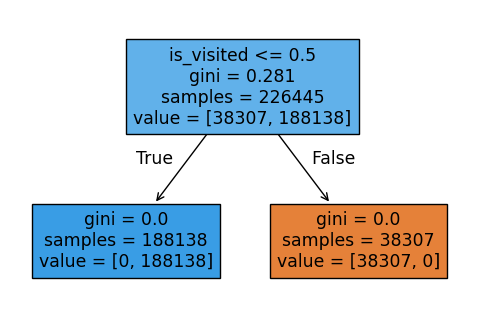

In [13]:
# nullの発生条件を決定木（Decision Tree）に予測させる

# あるカラムがnullになるのはどんな条件のときなのかを機械学習モデルに逆探知（逆エンジニアリング）させる

# 例えばstore_idが nullかどうか（0か1か）を正解ラベルにして、浅い決定木（max_depth=2くらい）を学習させることで、store_idがnullになる条件をあぶり出す
from sklearn.tree import DecisionTreeClassifier, plot_tree
y_null = df1['store_id'].isnull().astype(int)  # store_idがnullなら1、値があるなら0というダミーの目的変数を作る
X_null = df1[['is_visited', 'app_pv', 'current_temp']].fillna(-999)  # 特徴量として、それ以外のカラムを使う
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_null, y_null)

# 木構造をプロットしてルールを目視
plt.figure(figsize=(6, 4))
plot_tree(tree, feature_names=X_null.columns, filled=True)
plt.show()

# 最初の分岐条件がis_visited<=0.5（is_visited==0なら100%nullになる）との結果
# どうやら来店してないときはstore_idがnullになるらしい。といったルールからデータセット構造を把握する手がかりになりそう

## null rate
- nullが全体に占める割合や、ユニークカウント値を集計
- その特徴量をどう扱うか、nullをどう扱うかの検討材料に（例えばnullはnullのままにしておく、レコード自体削除する、なんらか補完する、あまりにもnull率高い特徴量は使わないなど）
- データ構造の把握にも役立つ

In [14]:
def check_null_and_uniques(df, columns=None):
    """
    各カラムのnull率、ユニーク数などを集計するにゃん。
    df: 対象のデータフレーム
    columns: 集計したいカラムのリスト。省略（None）した場合は、すべてのカラムが対象    
    """
    if columns is None:
        target_df = df  # カラム未指定時は全カラムを対象にする
    else:
        if isinstance(columns, str):
            columns = [columns]  # 単一カラム指定時用
            
        # 指定されたカラムの中に、元のdfに存在しないものがないかチェック
        missing_cols = [c for c in columns if c not in df.columns]
        if missing_cols:
            raise ValueError(f"エラー：指定カラム {missing_cols} はそのデータフレームに存在しないにゃん!")
            
        # 指定されたカラムだけに絞り込む
        target_df = df[columns]

    total_rows = len(target_df)
    null_counts = target_df.isnull().sum()
    non_null_counts = total_rows - null_counts
    unique_counts = target_df.nunique()

    report_df = pd.DataFrame({
        'type': target_df.dtypes,                              # データ型
        'total_count': total_rows,                            # 全体の行数（null率の分母）
        'non_null': non_null_counts,                          # 非欠損値の行数
        'null': null_counts,                                  # 欠損値の数
        'null_rate(%)': (null_counts / total_rows * 100),     # 欠損率（%）全体の何％が欠損しているか
        'unique': unique_counts,                              # ユニーク数
        'non_null/unique': non_null_counts / unique_counts   # 頻度（1ユニークあたりの平均行数）
    })

    return report_df.sort_values(by='null', ascending=False).round(2)  # nullの数が多い順でソート


# 実行
check_null_and_uniques(df1)

# null相関が1だった4カラムは当然null率が同じ、null率自体高い
# null相関がほぼ0だった2カラムのnull率は微量
# 全体のレコード数とユニークカウント値との桁数の違いも、データ構造を推し量る材料になる
# 例えば22万行あるが、dateは91日分ということは、1つのdateが何度も登場するらしい。同様にcustomer_idも1万弱なので同じ顧客が何度も登場するらしい。そして22万行あるが、日付×顧客IDがこのデータセットの最小単位なのでdate91日×customer_id1万人=91万件　よりは少ないので、全員が毎日登場するわけではないらしいこともみえてくる

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
store_id,str,226445,38307,188138,83.08,20,1915.35
is_raining,float64,226445,38307,188138,83.08,2,19153.50
station_congestion_index,float64,226445,38307,188138,83.08,910,42.10
daily_staffing_cost,float64,226445,38307,188138,83.08,903,42.42
current_temp,float64,226445,219652,6793,3.00,91,2413.76
app_pv,float64,226445,224181,2264,1.00,29,7730.38
date,datetime64[us],226445,226445,0,0.00,91,2488.41
customer_id,str,226445,226445,0,0.00,9994,22.66
membership_days,object,226445,226445,0,0.00,1002,225.99
is_visited,int64,226445,226445,0,0.00,2,113222.50


## null or not
- nullのTrue/False別で、主要カラムを集計してみる
- 集計値に大きな違いがあるようなら、null自体が特徴量として意味がある、null発生に規則性があるなどと判断しやすい
- nullの扱いをどうするかの検討材料にもなる

In [15]:
def check_nan_impact(df, target_nan_col, metrics_cols):
    """
    nullを含むカラムをnull or not別に、数値型カラム（目的変数や主要カラム）の平均値を比較するにゃん。
    """
    res = df.groupby(df[target_nan_col].isna())[metrics_cols].mean().round(4)
    # 対象カラム自体の件数(行数)をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "count", df.groupby(df[target_nan_col].isna()).size())
    return res

In [16]:
# nullを含むカラム一覧
print(check_null_and_uniques(df1).query('null > 0').sort_values('null', ascending=False).index.tolist())

# これらのカラムを主に対象としてみていく

['store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost', 'current_temp', 'app_pv']


In [17]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "store_id", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
store_id,,,,
False,38307,0.2883,1.0,5.2559
True,188138,0.0000,0.0,1.1827


In [18]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "is_raining", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
is_raining,,,,
False,38307,0.2883,1.0,5.2559
True,188138,0.0000,0.0,1.1827


In [19]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "station_congestion_index", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
station_congestion_index,,,,
False,38307,0.2883,1.0,5.2559
True,188138,0.0000,0.0,1.1827


In [20]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "daily_staffing_cost", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
daily_staffing_cost,,,,
False,38307,0.2883,1.0,5.2559
True,188138,0.0000,0.0,1.1827


- null相関が1だった4カラムは主要カラムの集計値が同じだった
- どうやら'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'たちは、is_purchased, is_visitedが0だとnullらしい
- そしてnullかそうでないかで主要カラムの集計値に大きな違いがあった。すなわち、nullの発生には規則性がありそうなことがわかる（データセットの構造的要因に起因しそう）
- （is_purchased, is_visitedについても、その名称からすると来店してない時は購入してない扱いのデータ構造になってるかも、まで類推しちゃうかも）

In [21]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "current_temp", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
current_temp,,,,
False,219652,0.0487,0.1691,1.8723
True,6793,0.0515,0.1703,1.8500


In [22]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "app_pv", ["is_purchased", "is_visited", "current_temp"])

,count,is_purchased,is_visited,current_temp
app_pv,,,,
False,224181,0.0488,0.1691,17.852
True,2264,0.0477,0.1723,17.922


- null相関がほぼ0だった2カラムは、nullかそうでないかで主要カラムの集計値に大きな違いはなかった
- どうやら'current_temp', 'app_pv'のnullは、MAR(Missing At Random) すなわちnull発生に規則性はなさそう

## where null
- nullの出現の仕方に規則性があるか（nullが特定のセグメントや条件で発生、集中していそうか）をみる
- nullの相関（共起性）をみた際に（null check工程）、相関係数がほどほどにあったカラムたちが主に対象（このデータセットでは存在しない）
- ここではstore_id, customer_idをみることで、データ構造の理解を深める

In [23]:
def check_nan_by_segment(df, group_col):
    """
    特定のセグメントにnullが集中していないかをチェックするにゃん。
    df: 対象のデータフレーム
    group_col: 集計の軸にするセグメントのカラム名（例: 'store_id'）
    """
    # 1. 軸になるカラム自体のnullを除外して考える（念のため）
    # 2. 各行がnull（True/False）のデータフレームを作り、group_col でグループ化して合計（件数）を出す
    null_counts_by_grp = df.isnull().groupby(df[group_col]).sum()

    # 3. nullが1件でも存在するカラムだけに絞り込む
    target_nan_cols = null_counts_by_grp.columns[null_counts_by_grp.sum() > 0]

    if len(target_nan_cols) == 0:
        print("🎉 nullを含むカラムは存在しなかったにゃん")
        return None

    res_df = null_counts_by_grp[target_nan_cols]  # 絞り込んだ結果のデータフレーム
    res_df["total_null_count"] = res_df.sum(axis=1)  # nullが登場するカラムたちの値を横方向に合計した列を追加
    group_sizes = df.groupby(group_col).size().to_frame(name="count")  # 各セグメントの件数count（分母）を集計
    final_res = group_sizes.join(res_df)  # 横に結合

    return final_res

In [24]:
# 特定のカラム（nullの出現の仕方に規則性ありそうと目されるもの）とdataframeを指定して実行
check_nan_by_segment(df1, group_col='store_id').head(15)  # 出力件数が多い場合を考慮してhead指定

# store_idのnull出現に規則性なさそうなことはわかっててそれを追認した形
# ただし、なんだか表記揺れが発生していそうな雰囲気が感じられる

,count,app_pv,current_temp,total_null_count
store_id,,,,
Store_A,3703,34,116,150
Store_B,3740,31,125,156
Store_C,3643,45,111,156
Store_D,3572,37,98,135
Store_E,3841,39,105,144
Store_F,4094,45,126,171
Store_G,3691,27,102,129
Store_H,3784,46,114,160
Store_I,3911,50,119,169


In [25]:
# 特定のカラム（nullの出現の仕方に規則性ありそうと目されるもの）とdataframeを指定して実行

# customer_idは出力件数が多すぎてheadでは状況不明なので、ソートして上位を表示
check_nan_by_segment(df1, group_col='customer_id').sort_values('total_null_count', ascending=False).head(15)

# customer_idにはもともとnullはないし、集計対象カラムたちのnull発生にも規則性はなさそう
# null出現に不審点ある場合は、さらに特定のカラムでソートしたり、比率など計算のうえdataframeに格納してチェックするとよい

,count,app_pv,store_id,current_temp,is_raining,station_congestion_index,daily_staffing_cost,total_null_count
customer_id,,,,,,,,
mwhl9pz2,70,1,65,2,65,65,65,263
wb8nbspy,72,0,64,2,64,64,64,258
356f9bg3,72,0,64,2,64,64,64,258
60vkejco,68,0,63,1,63,63,63,253
eqh7iw8g,75,0,63,1,63,63,63,253
4fjgutcv,67,0,63,0,63,63,63,252
n7a55xul,69,1,62,2,62,62,62,251
t2ne0d2c,71,0,61,5,61,61,61,249
an8a0v7i,67,1,60,5,60,60,60,246


- データ理解の構造についてのまとめ
  - null出現に規則性のあるカラムと、randomなカラム（null件数は少ない）があった
  - nullをどう扱うかはここではいったん保留
  - データ構造はなんとなくみえてきた
  - 副産物として変なデータが混入してそうなことがわかったので次の工程でクリーニングしていく

# Data Cleaning

## dtypes number
- 数値型扱いになっているが、例えばカテゴリ変数や文字列として扱いたいカラムが混ざっていないか？のチェック
  - 非数値型を思わせるid/code/typeのような文字を含むカラム名だったり、ユニーク数が極端に少ないカラムなど
  - yyyymmddが年/月/日に分かれて格納されてるなど、hh時間帯や曜日など
  - 顧客属性やなんらかの区分を表す名義尺度のような情報が数値で格納されているなど
- 自作関数で洗い出したり、ユニーク値を目視していく（要約統計量をみるのもいい）

In [26]:
# データ型の把握（数値型のみ）
df1.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_pv                    224181 non-null  float64
 1   is_visited                226445 non-null  int64  
 2   is_purchased              226445 non-null  int64  
 3   current_temp              219652 non-null  float64
 4   is_raining                38307 non-null   float64
 5   station_congestion_index  38307 non-null   float64
 6   daily_staffing_cost       38307 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 12.1 MB


In [27]:
def suggest_non_number_columns(df):
    """
    数値型だけど、実は非数値型（カテゴリ型やフラグ型）かもしれないカラムを提案するにゃん。
    """
    suspicious_cols = []
    
    for col in df.select_dtypes(include=['number']).columns:
        unique_count = df[col].nunique()
        
        # 条件A: カラム名に識別子を思わせるキーワードが含まれているか
        has_keyword = any(keyword in col.lower() for keyword in ["id", "code", "type", "day", "flag"])
        
        # 条件B: ユニークな値の数が極端に少ないか（例：0と1の2種類など5件以下）
        is_low_cardinality = unique_count <= 5
        
        # 条件A、または条件Bのどちらかを満たしたら怪しいと判定する
        if has_keyword or is_low_cardinality:
            suspicious_cols.append((col, unique_count))
            
    if suspicious_cols:
        print("💡 以下の数値型カラムは、非数値型（カテゴリやBool）に変えたほうがいいかもしれないにゃん：")
        for col, count in suspicious_cols:
            print(f"   ∟ {col} (ユニーク値: {count}件)")
    else:
        print("✅ 数値型カラムに非数値型っぽいものは見当たらないにゃん。")

# 実行
suggest_non_number_columns(df1)

# 出力結果は指定ルールにヒットしたものをあくまで提案してるだけなので、実際に変えるかは以降内容踏まえて都度判断する

💡 以下の数値型カラムは、非数値型（カテゴリやBool）に変えたほうがいいかもしれないにゃん：
   ∟ is_visited (ユニーク値: 2件)
   ∟ is_purchased (ユニーク値: 2件)
   ∟ is_raining (ユニーク値: 2件)


In [28]:
# 提案されたカラムはいずれもcategory型やboolにする必要性は薄いんだが、変更を検討する場合を想定して、

print(df1['is_raining'].unique())  # ユニーク値の種別を把握
df1.groupby('is_raining').size()  # ユニーク値別に頻度（行数）を見てみる

# このカラムは（2値なので）数値型扱いでも支障なさそうなのでこのままとする

[nan  0.  1.]


is_raining
0.0    30825
1.0     7482
dtype: int64

In [29]:
# # 数値型カラムのうち、数値型の必要性がないカラムを文字列型に変換するなら、
# df1["value_id"] = df1["value_id"].astype('str') 
# df1["value_id"] = df1["value_id"].astype('string')   # pandasが古い例えばv1.5とかならstringを指定した方がいいかも

# # NaNはNaNのまま残して、数字だけを文字列（str）に変換する
# df1["value_id"] = df1["value_id"].map(lambda x: str(int(x)) if pd.notnull(x) else x)
# # ※小数点以下も含むような数値を想定して、int(x)を挟んでからstr()にしている

In [30]:
# 数値型カラムのうち、カテゴリ変数にしたいカラムを型変換するなら、

# 一度文字列にしてからcategory型にする
# df1["value_id"] = df1["value_id"].astype(str).astype("category")

# 順序に意味があるカテゴリ変数にしたい場合（満足度 high/mid/lowや曜日など）
# 並び順を指定してcategory型にする
# weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# df1["weekday"] = pd.Categorical(df1["weekday"].astype(str), categories=weekday_order, ordered=True)
# 特徴量として使う際に、モデルがこの並び順でなんらか傾向があるかも？と並び順の情報を保持したまま学習してくれる

In [31]:
# 数値型カラムのうち、明らかにyyyymmddなのでdatetime型に変換するなら、
# df1["date"] = pd.to_datetime(df1["date"].astype(str))　　# 一度文字列にしてから変換

# 数値型カラムのうち、例えばyyyymmddが年/月/日に分かれて格納されてるのを、束ねてdatetimeに型変換するなら、
# カラム名が 'year', 'month', 'day' ならこれで
# df1['date'] = pd.to_datetime(df1[['year', 'month', 'day']])
# あるいは辞書形式で指定する
# df1['date'] = pd.to_datetime({'year': df1['yyyy'], 'month': df1['mm'], 'day': df1['dd']})

## dtypes exclude number
- 非数値型扱いになっているが、数値として扱いたいカラムが混ざっていないか？のチェック
  - 連続値データだけと思ってたら、?や空文字（スペースだけ）のような文字が混入しているなど
  - エクセルで数値の先頭に'をつけてたり、エクセル書式で文字列設定していた影響が残っているなど

In [32]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             226445 non-null  datetime64[us]
 1   customer_id      226445 non-null  str           
 2   membership_days  226445 non-null  object        
 3   store_id         38307 non-null   str           
dtypes: datetime64[us](1), object(1), str(2)
memory usage: 6.9+ MB


## why not numeric
- 文字列カラム（str, string, object）の中身を把握
- 数値型であって欲しいのに、文字列扱いになっているカラムへの混入物を目視したい意図（isnullではヒットしない）

In [33]:
# チェックしたいカラムをリストアップ（文字列扱いカラムのうち、そうであって欲しくないカラムのみ）
# ここでは文字列扱いじゃないカラムもうっかり含めちゃった想定にしている（自作関数のフィルタチェック目的でもある）
target_numeric_cols = ['membership_days', 'app_pv', 'current_temp']

In [34]:
def scan_numeric_columns(df, target_cols):
    """
    数値型であって欲しいカラムをスキャンし、数値以外のデータが混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのカラムだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---")
    total_count = len(df)
    
    for col in check_cols:
        # 1. もともとnullだった数をカウント
        original_nan_count = df[col].isna().sum()
        original_nan_rate = (original_nan_count / total_count) * 100
        
        # 2. 数値に変換を試みる（数値にできないエラーのぶんは強制的にNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # 3. もともとnullではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        # 画面に出力するフェーズ
        print(f"⚠️ {col}")
        print(f"   ∟ 総行数: {total_count:,} 件")
        print(f"   ∟ ① もともとの欠損値(Null)   : {original_nan_count:,} 件 ({original_nan_rate:.2f} %)")
        
        if not non_numeric_rows.empty:
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            trash_rate = (total_non_numeric / total_count) * 100
            
            print(f"   ∟ ② 数値以外のデータ : {total_non_numeric:,} 件 ({trash_rate:.2f} %)")
            print(f"      [詳細内訳]")
            for val, cnt in counts.items():
                # 空文字（長さ0）はわかりにくいので、明示的にテキスト表現する
                display_val = '"" (空文字)' if str(val).strip() == '' else f"'{val}'"
                print(f"         - {display_val}: {cnt:,} 件")
        else:            
            print(f"   ∟ ② 数値以外のデータ : 0 件 (0.00 %) -> 混入物なし！")
            
        print("-" * 45)

In [35]:
scan_numeric_columns(df1, target_numeric_cols)

# membership_daysはカラム名からすると数値型っぽいがそうなってなかったのは、'?'や''が混入してたからと判明
# 混入物が占める割合は多くはない
# だがnullの件と同様に、この混入物がどんな条件のときに発生しているのか（規則性あるか）を見ておく

--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---
⚠️ membership_days
   ∟ 総行数: 226,445 件
   ∟ ① もともとの欠損値(Null)   : 0 件 (0.00 %)
   ∟ ② 数値以外のデータ : 1,808 件 (0.80 %)
      [詳細内訳]
         - '?': 1,129 件
         - "" (空文字): 679 件
---------------------------------------------


In [36]:
def check_trash_impact(df, target_col, metrics_cols):
    """
    数値型であって欲しいカラムを状態別に、数値型カラム（目的変数や主要カラム）の平均値を比較するにゃん。
    """
    # 1. 状態を判定するためのベース（文字列化して前後の空白を削除）
    col_str = df[target_col].astype(str).str.strip()
    
    # 2. 条件分岐用のマスクを作成（ここの定義を増やせば拡張可能。check_nan_impact関数の上位互換）
    is_real_nan = df[target_col].isna()
    is_q_mark = (col_str == '?')
    is_empty = (col_str == '')
    
    # 3. 状態を定義するラベルのSeriesを生成
    # デフォルトを「正常（数値）」にしておき、各条件に合う場所を上書きする
    status_series = pd.Series("0_正常（数値）", index=df.index)
    status_series[is_real_nan] = "1_欠損（NaN）"
    status_series[is_q_mark] = "2_ゴミ（'?'）"
    status_series[is_empty] = "3_ゴミ（空文字）"
    
    # 4. 作成したラベルでgroupbyをかけ、主要指標の平均値を計算
    res = df.groupby(status_series)[metrics_cols].mean().round(4)
    
    # 5. 各状態の件数（行数）をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "count", df.groupby(status_series).size())
    
    print(f"📊 {target_col}")
    return res

In [37]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_trash_impact(df1, "membership_days", ["is_purchased", "is_visited", "app_pv", "current_temp"])

# どうやら混入物の発生に規則性はなさそう
# だがこの自作関数はmeanを計算しているため文字列型カラムなどについては判定不能なことから以下もおこなう（例えば特定のstore_idでのみ混入物が発生している可能性は残る）

📊 membership_days


,count,is_purchased,is_visited,app_pv,current_temp
0_正常（数値）,224637,0.0487,0.1691,1.8709,17.8529
2_ゴミ（'?'）,1129,0.0531,0.1771,1.9830,17.8153
3_ゴミ（空文字）,679,0.0501,0.1723,1.9156,17.8271


In [38]:
def check_category_trash_impact(df, target_col, cat_col):
    """
    数値型カラムの混入物が、特定のセグメント、カテゴリに集中（偏って）発生していそうかをみるにゃん。
    """
    # 1. 状態のラベルSeriesを作る（ここの定義を増やせば拡張可能）
    col_str = df[target_col].astype(str).str.strip()
    status_series = pd.Series("0_正常", index=df.index)
    status_series[df[target_col].isna()] = "1_欠損（NaN）"
    status_series[col_str == '?'] = "2_ゴミ（'?'）"
    status_series[col_str == ''] = "3_ゴミ（空文字）"
    
    # 2. クロス集計しつつ、行（状態）ごとの比率（normalize='index'）に変換する
    # それぞれの状態における指定セグメントのシェアを計算
    cross_pct = pd.crosstab(status_series, df[cat_col], normalize='index') * 100
    
    print(f'📊 "{target_col}" の混入物における、{cat_col}の構成比（%）')
    
    # 3. 各行（状態）ごとに、シェアが高い上位5つを抽出
    for status in cross_pct.index:
        print(f"\n▶️ 【{status}】での {cat_col}の上位シェア:")
        top5 = cross_pct.loc[status].sort_values(ascending=False).head(5)
        for cat, val in top5.items():
            print(f"   ∟ {cat}: {val:.2f} %")
            
    print("-" * 45)

In [39]:
check_category_trash_impact(df1, "membership_days", "store_id")

# 混入物状態におけるstore_idの出現率に極端な偏りはなさそう、正常データにおける出現率とも似た傾向を示している
# つまり特定のstore_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、store_idの構成比（%）

▶️ 【0_正常】での store_idの上位シェア:
   ∟ Store_J: 10.78 %
   ∟ Store_F: 10.74 %
   ∟ Store_I: 10.22 %
   ∟ Store_E: 10.03 %
   ∟ Store_H: 9.87 %

▶️ 【2_ゴミ（'?'）】での store_idの上位シェア:
   ∟ Store_A: 13.50 %
   ∟ Store_J: 12.50 %
   ∟ Store_G: 12.00 %
   ∟ Store_B: 10.50 %
   ∟ Store_H: 10.00 %

▶️ 【3_ゴミ（空文字）】での store_idの上位シェア:
   ∟ Store_B: 14.53 %
   ∟ Store_H: 13.68 %
   ∟ Store_C: 12.82 %
   ∟ Store_J: 12.82 %
   ∟ Store_E: 11.97 %
---------------------------------------------


In [40]:
check_category_trash_impact(df1, "membership_days", "date")

# 特定の日付でのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、dateの構成比（%）

▶️ 【0_正常】での dateの上位シェア:
   ∟ 2025-11-30 00:00:00: 1.40 %
   ∟ 2025-11-29 00:00:00: 1.37 %
   ∟ 2025-11-22 00:00:00: 1.37 %
   ∟ 2025-11-24 00:00:00: 1.37 %
   ∟ 2025-11-23 00:00:00: 1.35 %

▶️ 【2_ゴミ（'?'）】での dateの上位シェア:
   ∟ 2025-10-05 00:00:00: 2.04 %
   ∟ 2025-11-23 00:00:00: 1.86 %
   ∟ 2025-10-19 00:00:00: 1.59 %
   ∟ 2025-09-14 00:00:00: 1.59 %
   ∟ 2025-09-27 00:00:00: 1.59 %

▶️ 【3_ゴミ（空文字）】での dateの上位シェア:
   ∟ 2025-10-26 00:00:00: 2.36 %
   ∟ 2025-09-14 00:00:00: 2.21 %
   ∟ 2025-11-30 00:00:00: 2.06 %
   ∟ 2025-11-14 00:00:00: 2.06 %
   ∟ 2025-11-06 00:00:00: 1.77 %
---------------------------------------------


In [41]:
check_category_trash_impact(df1, "membership_days", "customer_id")

# 特定のcustomer_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、customer_idの構成比（%）

▶️ 【0_正常】での customer_idの上位シェア:
   ∟ eqh7iw8g: 0.03 %
   ∟ 356f9bg3: 0.03 %
   ∟ wb8nbspy: 0.03 %
   ∟ t2ne0d2c: 0.03 %
   ∟ rslxex03: 0.03 %

▶️ 【2_ゴミ（'?'）】での customer_idの上位シェア:
   ∟ cai4zq7i: 0.27 %
   ∟ lyu9wpn4: 0.27 %
   ∟ 64kqbc75: 0.27 %
   ∟ 4ma68ifi: 0.27 %
   ∟ vqzcghtl: 0.18 %

▶️ 【3_ゴミ（空文字）】での customer_idの上位シェア:
   ∟ g5sbjqlf: 0.29 %
   ∟ 14sz2k5u: 0.29 %
   ∟ 2wcupt8e: 0.29 %
   ∟ mol8hj7h: 0.29 %
   ∟ d15am9zm: 0.29 %
---------------------------------------------


In [42]:
# membership_daysカラムの混入物の発生に規則性はなさそう
# このカラムは数値型であって欲しいので、混入物はなんらかの処理をしておきたい
# 数値以外のデータが少数なことと、素早い初動回答を優先して、NaN（欠損値）に置換する
# NaNにすることが最善手かは不明だが、先に進むためにはいったんキレイに数値型にしておくほうが好都合

# 数値に変換を試みることで、数値にできない混入物は強制的にNaNにできる
df1['membership_days'] = pd.to_numeric(df1['membership_days'], errors='coerce')

In [43]:
# # 混入物の処理方法案

# # 不要な文字列は混入しているが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 数値にできない文字列は強制的にNaN（欠損値）に置換する（NaNを含むので自動的にfloat64型になる）
# df1['value1'] = pd.to_numeric(df1['value1'], errors='coerce')

# # この文字は0にしたい、この文字は欠損値扱いにしたいなどの明確な根拠、意思がある場合
# # replaceで明示的に特定の文字を、それぞれ置換してからastype
# df1['value1'] = df1['value1'].replace({'?': 0, 'Unknown': np.nan}).astype(float)  # ?は0に、UnknownはNaNに置換
# df1["value1"] = df1["value1"].replace(["", "?"], np.nan)  # 空白と?はNaNに置換

# # "1,200円"のように数字に関連する余計な文字がくっついている場合
# # 正規表現で数字以外を削ぎ落とす（数字、小数点、マイナス記号以外を全部消す）
# df1['value1'] = df1['value1'].str.replace(r'[^0-9.-]', '', regex=True).astype(float)

# # （混入物はなく明らかに全て数値情報のみなんだが）文字列扱いになっているカラムを、数値型に変換する
# df1["value1"] = df1["value1"].astype(float)

## why not datetime
- 時点情報のカラムがdatetime型になっていない原因を把握する
- 時点情報がdatetime型でなくとも不都合少ない場合もあるが、期間の計算やダウンサンプリングで苦労する

In [44]:
# datetime型であって欲しいのに、文字列扱いになっているカラムをリストアップ

# dateカラムがdatetime型なのはわかってるが、そうではなかった場合を想定して実行
target_datetime_cols = ['date']

In [45]:
def scan_datetime_columns(df, target_cols):
    """
    datetime型にしたいカラムをスキャンし、日付として読み取れない文字を特定するにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのものだけを抽出
    # datetime型に変換済みのカラムがtarget_date_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!")
        return

    print("--- 🔍 日付列のフォーマット不備チェック ---")
    for col in check_cols:
        # 日付型に変換を試みる（日付にできないエラーのぶんはNaNになる）
        converted = pd.to_datetime(df[col], errors='coerce')
        # もともとNaNではなく、日付変換によって新たにNaNになった値（＝混入物）を特定
        invalid_date_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not invalid_date_rows.empty:
            total_count = len(df)
            counts = invalid_date_rows.value_counts()
            total_invalid = counts.sum()
            rate = (total_invalid / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 日付にできないデータ: {total_invalid:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべての日付が正しく変換可能だにゃん!")

In [46]:
scan_datetime_columns(df1, target_datetime_cols)

✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!


In [47]:
# # 文字列扱いの日付データをdatetime型に変換する

# # 全カラムが明らかに日付情報のみであることが確実な場合に（文字列混入していると実行エラーになる）
# df1["date"] = pd.to_datetime(df1["date"])

# # 不要な文字列が混入してるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 日付にできない文字列は強制的にNaN（欠損値）に置換したうえで、削除する
# df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
# before_count = len(df1)  # 日付がNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['date']).reset_index(drop=True)  # 日付がNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # 日付がNaNの行を削除した後の行数
# print(f"日付不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# 日付データのカラムの中身がもっと変で複雑な場合は、適宜加工してキレイに変換する（ここでは省略）

## describe, histogram
クリーニング工程を（完全にではないがひとまず）終えて改めてみておく

- 数値型カラムの平均、標準偏差、最小値、最大値などを把握
  - 事前情報やドメイン知識からして極端な外れ値が混入していないかもチェックできるとなおよい
- 非数値型カラムのユニークカウント、最頻値、範囲などを把握

In [48]:
# データ型の把握（数値型のだけ）
df1.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   membership_days           224637 non-null  float64
 1   app_pv                    224181 non-null  float64
 2   is_visited                226445 non-null  int64  
 3   is_purchased              226445 non-null  int64  
 4   current_temp              219652 non-null  float64
 5   is_raining                38307 non-null   float64
 6   station_congestion_index  38307 non-null   float64
 7   daily_staffing_cost       38307 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 13.8 MB


In [49]:
# 数値型カラムの要約統計量
df1.describe(include='number')

,membership_days,app_pv,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost
count,224637.000000,224181.000000,226445.000000,226445.000000,219652.000000,38307.000000,38307.000000,38307.000000
mean,353.220266,1.871639,0.169167,0.048767,17.852683,0.195317,101.345516,98874.563631
std,274.800079,2.093322,0.374900,0.215381,4.312624,0.396450,15.294446,28314.078160
min,0.000000,1.000000,0.000000,0.000000,8.264353,0.000000,41.813966,50181.000000
25%,116.000000,1.000000,0.000000,0.000000,13.972718,0.000000,91.025140,74292.000000
50%,283.000000,1.000000,0.000000,0.000000,18.429534,0.000000,101.319641,98798.000000
75%,563.000000,2.000000,0.000000,0.000000,21.397737,0.000000,111.528600,122543.000000
max,999.000000,31.000000,1.000000,1.000000,25.498009,1.000000,154.915182,149992.000000


In [50]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         226445 non-null  datetime64[us]
 1   customer_id  226445 non-null  str           
 2   store_id     38307 non-null   str           
dtypes: datetime64[us](1), str(2)
memory usage: 5.2 MB


In [51]:
# 非数値型カラムの要約統計量
df1.describe(exclude='number')

,date,customer_id,store_id
count,226445,226445,38307
unique,NaN,9994,20
top,NaN,eqh7iw8g,Store_J
freq,NaN,75,4136
mean,2025-10-17 19:48:40.778113,NaN,NaN
min,2025-09-01 00:00:00,NaN,NaN
25%,2025-09-25 00:00:00,NaN,NaN
50%,2025-10-19 00:00:00,NaN,NaN
75%,2025-11-09 00:00:00,NaN,NaN
max,2025-11-30 00:00:00,NaN,NaN


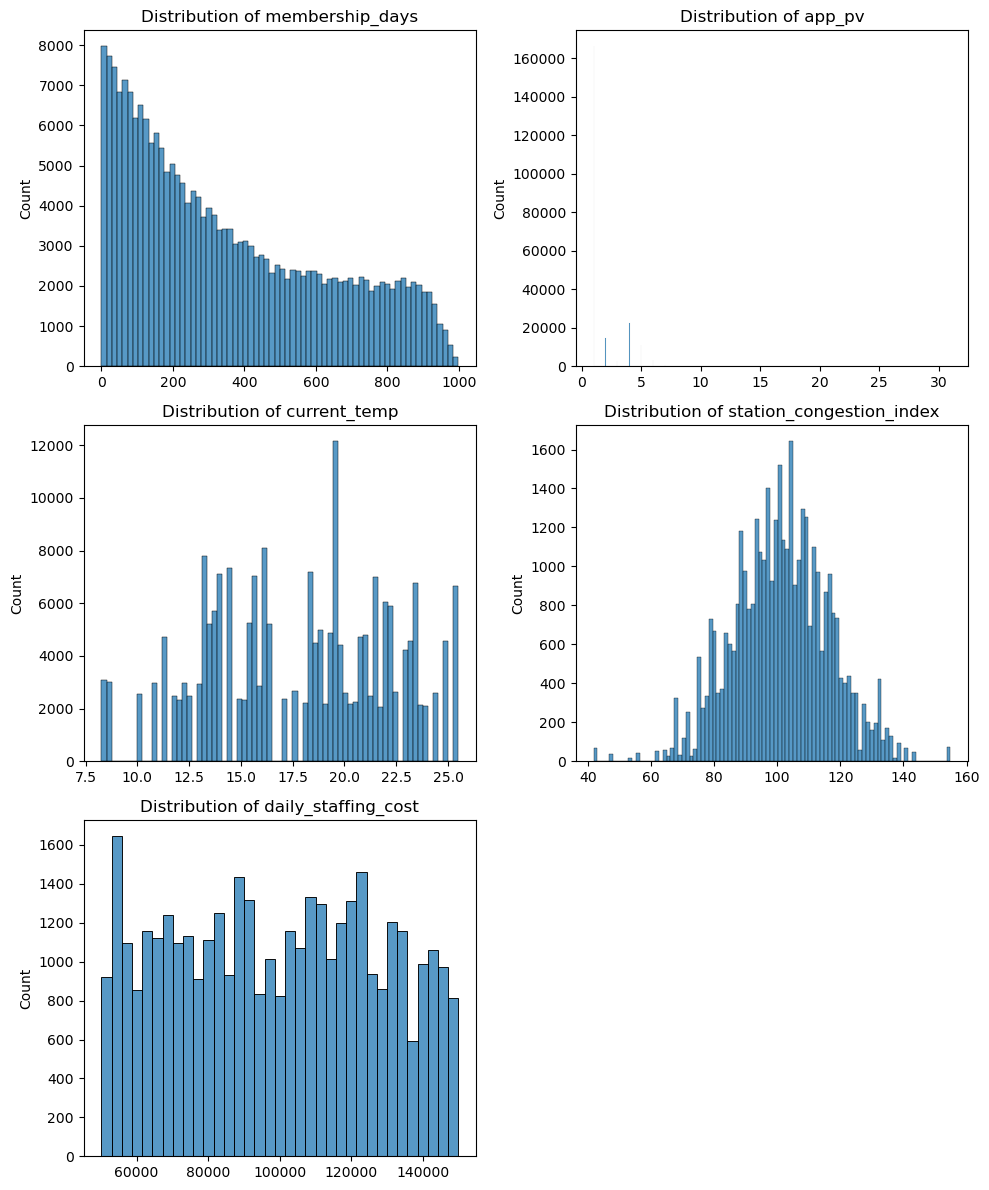

In [52]:
# 数値型カラムの分布をざっと見る

import math

# 分布を見たい数値型カラムをリスト指定
# num_features = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()  # 楽だが2値のも含まれちゃう
num_features = ['membership_days', 'app_pv', 'current_temp', 'station_congestion_index', 'daily_staffing_cost']

# レイアウトの計算（列数固定で、カラム数に応じて必要な行数を自動計算）
n_cols = 2
n_rows = math.ceil(len(num_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
# axesが1行（1次元）や1個（スカラー）のときでも、同じループで扱えるように1次元配列にフラット化
axes = axes.flatten()

# plot
for i, col in enumerate(num_features):
    sns.histplot(data=df1, x=col, kde=False, ax=axes[i])
    # sns.histplot(data=df1, x=col, kde=True, stat="density", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')  # タイトルに任せて消す

# 余った空っぽのマス（グラフ）を非表示にする
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## len datetime
- 時点データの範囲内において、途中の日付が抜けてる可能性あるかをチェック
- describeでわかる期間とユニーク値との照合でもいいが長期間だと瞬発的には判断しにくい

In [53]:
def check_date_continuity(df, date_col):
    """
    日付の連続性をチェックし、期間内で途中の日付が抜けたりしてないかをチェックするにゃん。
    """
    # 念のため、時間を切り捨てて「純粋な日付のみ」にしたSeriesを内部で作る
    pure_date = pd.to_datetime(df[date_col]).dt.date
    
    # 期間日数とユニーク数の計算
    date_span_days = (pure_date.max() - pure_date.min()).days + 1
    unique_date_count = pure_date.nunique()
    
    print(f"--- 📅 日付連続性スキャン: 【{date_col}】 ---")
    print(f"   ∟ 開始日: {pure_date.min()} 〜 終了日: {pure_date.max()}")
    print(f"   ∟ 理論上の期間日数: {date_span_days} 日")
    print(f"   ∟ 実際のユニーク日数: {unique_date_count} 日")
    
    if date_span_days == unique_date_count:
        print("✅ 欠損日なし: 途中日付が抜けることなく連続してるにゃん！")
        
    elif date_span_days > unique_date_count:
        missing_days = date_span_days - unique_date_count
        print(f"⚠️ 欠損日の可能性あり: 途中で抜けてる日付が【{missing_days}日分】あるにゃん。")
        
    else:
        print("🚨 警告: 期間日数よりもユニーク日付数の方が多いにゃん！")
        print("   ∟ 原因の可能性: 元のカラムに時分秒データが残ったままnunique()を計算しているか、異常な日付が混入してるかもにゃん。")

# 実行
check_date_continuity(df1, 'date')

--- 📅 日付連続性スキャン: 【date】 ---
   ∟ 開始日: 2025-09-01 〜 終了日: 2025-11-30
   ∟ 理論上の期間日数: 91 日
   ∟ 実際のユニーク日数: 91 日
✅ 欠損日なし: 途中日付が抜けることなく連続してるにゃん！


## categorical variable
- カテゴリ変数っぽいカラムの中身を確認してカテゴリ変数にする

In [54]:
# 特徴量の候補なのにcategory型ではないカラム、あるいはユニーク値が少ないカラムなどを目視チェック
df1['store_id'].unique()

# 前の工程ですでに判明してた通り、Store_A〜Store_Jのはずが、store_a〜store_jも混じっている
# さすがにこれは表記揺れだろうとみなして、深く追求はせずに名寄せをおこなう

<StringArray>
[      nan, 'Store_D', 'Store_J', 'Store_B', 'Store_I', 'Store_H', 'Store_C',
 'Store_E', 'Store_A', 'Store_G', 'Store_F', 'store_e', 'store_i', 'store_h',
 'store_j', 'store_f', 'store_d', 'store_a', 'store_g', 'store_b', 'store_c']
Length: 21, dtype: str

## name matching
表記揺れの名寄せ

In [55]:
# パターン1: マスタ情報（正規のリスト）を基準に名寄せする
# 正しいリストを基準にしてそこから外れている怪しい文字列を丸め込む、あるいは例外として検知する方法

# 1. 正規の店舗マスタ情報
valid_stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D', 'Store_E', 
                'Store_F', 'Store_G', 'Store_H', 'Store_I', 'Store_J']

store_mapping = {}
for raw_id in df1['store_id'].unique():
    
    # もしraw_idがnan(欠損値) だった場合は、辞書に登録せずスルーする
    if pd.isna(raw_id):
        continue
        
    # 完全に同じ、または大文字小文字を無視して一致するものをマスタから探す
    matched = [v for v in valid_stores if str(raw_id).strip().lower() == v.lower()]
    if matched:
        store_mapping[raw_id] = matched[0]  # 正しい表記（Store_Aなど）を割り当て
    else:
        store_mapping[raw_id] = 'Unknown_Store' # マスタにないものが含まれていた場合は識別できるようにしておく

# 3. 辞書形式で置換
df1['store_id'] = df1['store_id'].replace(store_mapping)

In [56]:
# # パターン2: 辞書形式で直に置換する
# # 変換用の辞書定義
# dirty_to_clean_store = {
#     'store_a': 'Store_A', 'store_b': 'Store_B', 'store_c': 'Store_C', 
#     'store_d': 'Store_D', 'store_e': 'Store_E', 'store_f': 'Store_F', 
#     'store_g': 'Store_G', 'store_h': 'Store_H', 'store_i': 'Store_I', 'store_j': 'Store_J'
# }
# # 辞書に存在するものだけを置換し、それ以外（もともとちゃんとしていたStore_Aなど）はそのままキープする
# df1['store_id'] = df1['store_id'].replace(dirty_to_clean_store)

In [57]:
df1['store_id'].unique()

# 表記揺れはなくなったが、並び順を整えつつcategory型にしたい

<StringArray>
[      nan, 'Store_D', 'Store_J', 'Store_B', 'Store_I', 'Store_H', 'Store_C',
 'Store_E', 'Store_A', 'Store_G', 'Store_F']
Length: 11, dtype: str

In [58]:
# 特徴量に使う予定のカラム、あるいは文字列では不都合のあるカラムを、category型に変換するなら、

# 特徴量に使うので、store_idをソートしてcategory型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
# store_order = sorted(df1['store_id'].unique())  # ただしnullがあるとこれはエラーになる
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# nanをなくしてから unique() を取る
store_order = sorted(df1['store_id'].dropna().unique())

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)
df1['store_id'].unique()

[NaN, 'Store_D', 'Store_J', 'Store_B', 'Store_I', ..., 'Store_C', 'Store_E', 'Store_A', 'Store_G', 'Store_F']
Length: 11
Categories (10, str): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'Store_G' < 'Store_H' < 'Store_I' < 'Store_J']

## nullどうするか
- nullのままでもいいし、後述の前処理をおこなうのもよい。
- ただしnullをなくせばいいわけではない。むしろnullはnullのままの方がいいかも。
  - 例えばnullを0とみなして差し支えない場合はいいが、気温カラムのnullを0埋めするとおかしなことになる
  - また、LGBMはnullを欠損扱いで学習できるから、確からしい理由がない限りは無理に0で埋めずそのままの方が精度出やすい可能性ある

- 仮に過去購入率というカラムのnullを0に置換した場合
  - LGBMは0という具体的な数値として扱う。例えば購入率が0.05以下か？という境界線を作ったとき、0に置換されたデータ（みなし新規顧客）と、購入率がすごく低い既存客が同じグループにまとめられる。みなし新規顧客と既存顧客の購入率0を区別しなくていいならこれでもOK。

- 仮に過去購入率のnullをnullのままの場合
  - LGBMは数値がある人と、ない人（null）を、まず最初に分けることができる。データがあるかないかで枝分かれさせてから、データがある人の中で購入率が0.05以下か？とさらに細かく分けるという動きができる。つまり、新規客（未知）と、既存客の購入率0（既知のゼロ）を明確に使い分けられる可能性がある。

In [59]:
# # nullがあるとわかってるが、少数であったり規則性もなさそうなので影響軽微と許容できる場合

# before_count = len(df1)  # current_tempカラムがnullの行を削除する前の行数
# df1 = df1.dropna(subset=['current_temp']).reset_index(drop=True)  # 当該カラムがnullの行を削除してインデックスを振り直す
# after_count = len(df1)  # current_tempカラムがnullの行を削除した後の行数
# print(f"current_temp不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

In [60]:
# # nullの処理方法に、明確な根拠、意思がある場合

# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# # nullは0に置換するカラムを直接書き換える（例えば新規顧客とみなして0に置換する例）
# df1['past_latte_ratio'] = df1['past_latte_ratio'].fillna(0)

# # 辞書で渡す（例えば数値は0にして、カテゴリは'unknown'にする）
# df1 = df1.fillna({'past_latte_ratio': 0, 'value1': 'unknown'})

# # その他一般的なnullの処理方法については、例えば以下
# # # 数値データのnullを、平均値や中央値などの代表値で埋める
# # from sklearn.impute import SimpleImputer
# # imputer = SimpleImputer(strategy='mean')  # 平均値で埋める場合
# # df1['current_temp'] = imputer.fit_transform(df1[['current_temp']])

- ここまでみてきた限り、null出現に規則性のあるカラムはデータ構造に理由がありそう。
- そしてnull出現に規則性がなさそうなカラムにおいては、nullの占める割合は少なく影響軽微と許容できる
- というかnullを削除や置換する積極的理由は乏しいことと、lightgbmの場合はnullをそのまま扱えること、そして素早い初動回答を優先して、いずれの対象カラムもnullはそのままとする

## sort values
- 日付列がdatetime型になっても、データセットが日付順にソートされてないとモデル作成時に困る
- category型も、場合によってはソートされてないと不都合
- ただしソート対象のカラムにnullがあると、ソートしてもnullは先頭や末尾に固まって困るため、ソートする前にnullは適切処理しておく

In [61]:
# チェックしたいカラムをリストアップ

# datetime型や文字列扱いのカラムを投入する
# 顧客idのように並び順に意味がないものや、sort不要なものは含めない
target_cols = ['store_id', 'date']

In [62]:
from pandas.api import types

def check_sort(df, target_cols):
    """
    指定カラムがソートされた状態かチェックするにゃん。
    数値型の場合はスキップし、それ以外は型に合わせて賢くチェックするにゃん。
    """
    for col in target_cols:
        # 1. カラムが存在するかチェック
        if col not in df.columns:
            print(f"❓ {col} はデータフレームに存在しないみたいにゃん。")
            continue

        # 2. 型の判定（Pandas標準の判定メソッドを使う）
        if types.is_numeric_dtype(df[col]):
            print(f"🔢 {col}: これは数値型だにゃん。ソートチェックはスキップするにゃん。")
            continue
        
        # 3. 出現順のチェック
        # unique() は datetime や category でもそのまま使える
        # ただし、NaNが含まれるとsorted()でコケることがあるのでdropna()しておく
        actual = df[col].dropna().unique().tolist()
        expected = sorted(actual)
        
        # 4. 判定と表示
        if actual == expected:
            print(f"✅ {col}: このカラムの並び順はソートされてそうだにゃん！")
        else:
            print(f"❌ {col}: あれ、並び順が理想と違うにゃん")

# 実行
check_sort(df1, target_cols)

# ただしここではdropnaして実行している。よってnullがある場合のnull扱いは別途検討する必要あり

❌ store_id: あれ、並び順が理想と違うにゃん
❌ date: あれ、並び順が理想と違うにゃん


In [63]:
# 時点順にソートする（時点カラムがdatetime型になってる前提）

# df1 = df1.sort_values(by=['date']).reset_index(drop=True)

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる（時点カラムがdatetime型になってる前提）
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

# 実行
check_sort(df1, target_cols)

✅ store_id: このカラムの並び順はソートされてそうだにゃん！
✅ date: このカラムの並び順はソートされてそうだにゃん！


## time series y
- 目的変数の、時点推移の確認
- 日が経つにつれて傾向が変化しているか。周期性がありそうか

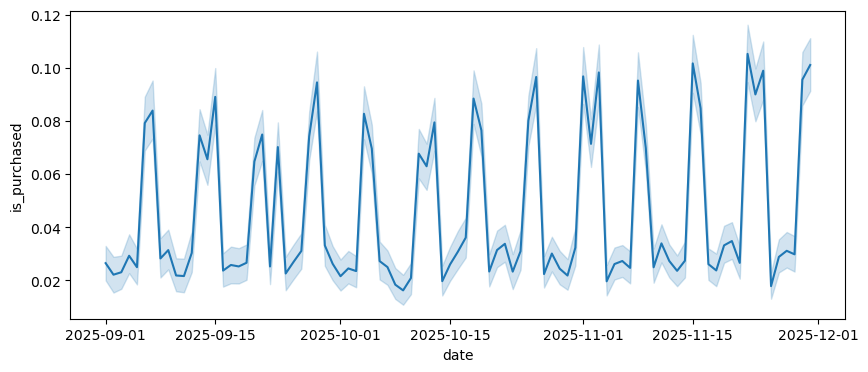

In [64]:
# 目的変数(is_purchased)の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['is_purchased'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="is_purchased", errorbar="ci")
plt.show()

# トレンドは右肩上がりになってるかもだし、大差ないかも
# 曜日の周期性のようなものがあるかもしれない

In [65]:
# 日付型のカラムから特徴量を作成
# 特徴量として使えるように数値型に分解する（必要に応じてカテゴリ型に変換する）

# df1['year']        = df1['date'].dt.year          # 年（2025など）
# df1['month']       = df1['date'].dt.month         # 月（1～12）
# df1['day']         = df1['date'].dt.day           # 日（1～31）
# df1['hour']        = df1['date'].dt.hour          # 時間（0～23）朝と昼の違い

df1['day_of_week_num'] = df1['date'].dt.dayofweek     # 曜日フラグ（0:月, 1:火 ... 6:日）
# df1['is_weekend']  = df1['date'].dt.dayofweek >= 5 # 週末フラグ（True/False）
df1['is_weekend'] = df1['date'].dt.dayofweek.isin([5, 6]).astype(int)  # 土日フラグ（5:土曜日, 6:日曜日）

In [66]:
# 経過日数を用意する

# データセット内の最古時点を1始まりとした（絶対的な）数値カラム
# df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があっても最古日からの経過日数になる

day_of_week_num
0    0.0499
1    0.0293
2    0.0257
3    0.0260
4    0.0281
5    0.0857
6    0.0804
Name: is_purchased, dtype: float64


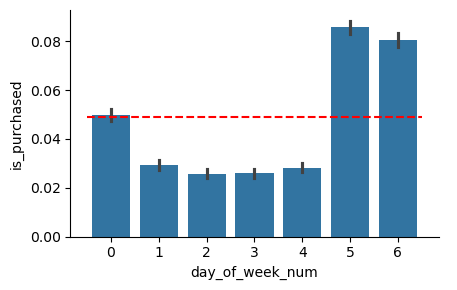

In [67]:
# 曜日別の購入率を見てみる
print(df1.groupby('day_of_week_num')['is_purchased'].mean().round(4))


# グラフで確認
sns.catplot(data=df1, x="day_of_week_num", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['day_of_week_num'].unique()))
plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['day_of_week_num'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
# plt.xticks(rotation=90)
plt.show()

# 土日は購入率高い（なので土日フラグという特徴量を作るのがよさそう）
# 平日のうち月曜だけなんか高い。他の曜日はほぼ同じ。月曜はひょっとしたら祝日発生しやすいぶんで高くなってる可能性あるかも

In [68]:
# データセットの期間内の祝日をみてみる

import jpholiday
start, end = df1['date'].min(), df1['date'].max()  # df['ds'] から期間の開始日と終了日を取得
years = df1['date'].dt.year.unique()  # 年をまたぐ可能性考えて、ユニークな年を取得

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name, 'day_of_week': pd.to_datetime(date).dayofweek, 'day_of_week_en': pd.to_datetime(date).strftime('%a')})
holidays_df = pd.DataFrame(holidays_list)
holidays_df

# 期間内の祝日6日間のうち月曜は4日だった

,ds,holiday,day_of_week,day_of_week_en
0,2025-09-15,敬老の日,0,Mon
1,2025-09-23,秋分の日,1,Tue
2,2025-10-13,スポーツの日,0,Mon
3,2025-11-03,文化の日,0,Mon
4,2025-11-23,勤労感謝の日,6,Sun
5,2025-11-24,勤労感謝の日 振替休日,0,Mon


In [69]:
# 祝日フラグの特徴量を作成する
df1['is_holiday'] = df1['date'].isin(holidays_df['ds']).astype(int)

In [70]:
# 曜日x祝日x週末別の購入率を計算
df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_purchased'].mean().round(4)

day_of_week_num  is_holiday  is_weekend
0                0           0             0.0262
                 1           0             0.0917
1                0           0             0.0254
                 1           0             0.0702
2                0           0             0.0257
3                0           0             0.0260
4                0           0             0.0281
5                0           1             0.0857
6                0           1             0.0795
                 1           1             0.0900
Name: is_purchased, dtype: float64

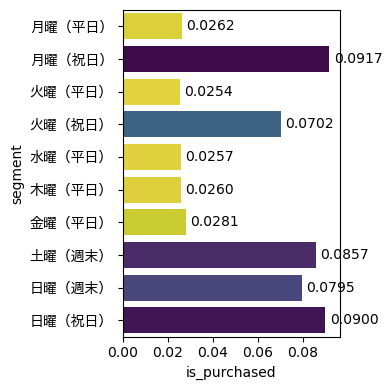

In [71]:
# グラフで確認してみる

#　上記集計値をdataframeにして
df_agg = (df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_purchased'].mean().reset_index())

# 曜日数値を日本語に
weekday_map = {0: '月', 1: '火', 2: '水', 3: '木', 4: '金', 5: '土', 6: '日'}
df_agg['day_name'] = df_agg['day_of_week_num'].map(weekday_map)

# 3つのフラグを組み合わせて人間が読めるセグメント名にする
def make_segment_name(row):
    if row['is_holiday'] == 1:
        return f"{row['day_name']}曜（祝日）"
    elif row['is_weekend'] == 1:
        return f"{row['day_name']}曜（週末）"
    else:
        return f"{row['day_name']}曜（平日）"

df_agg['segment'] = df_agg.apply(make_segment_name, axis=1)
# df_agg = df_agg.sort_values('is_purchased', ascending=False)  # 購入率の高い順でソート

# plot
plt.rcParams["font.family"] = ["sans-serif", "Hiragino Sans"]  # mac用
plt.figure(figsize=(4, 4))
sns.barplot(data=df_agg, x='is_purchased', y='segment', hue='is_purchased', palette='viridis_r')
# 数値を棒の横にテキスト表示
for index, row in enumerate(df_agg.itertuples()):
    plt.text(row.is_purchased + 0.002, index, f"{row.is_purchased:.4f}", va='center', fontsize=10)
plt.legend().remove()  # 凡例消す
plt.tight_layout()
plt.show()

# 平日のうち月曜だけ高かったのと、火曜がちょい高かったのは祝日の影響だったらしいことが判明
# なので土日フラグだけでなく、祝日フラグも特徴量として有効と思われる

## time series feature
- 目的変数以外の数値カラムについて、時点推移の確認
- 日が経つにつれて傾向が変化しているか。周期性がありそうか

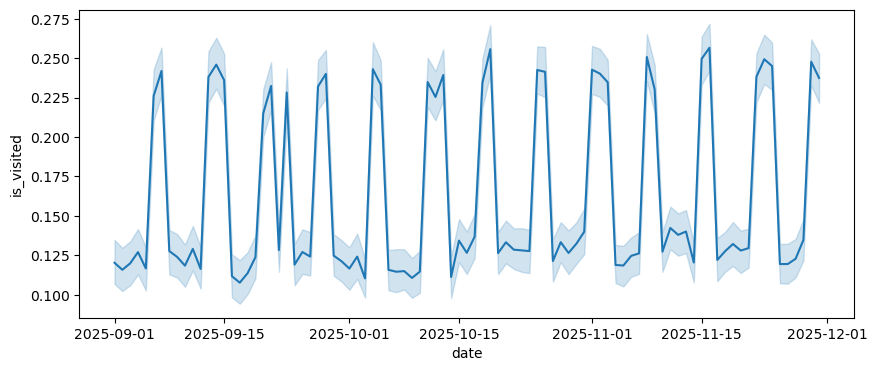

In [72]:
# 来店有無の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['is_visited'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="is_visited", errorbar="ci")
plt.show()

# トレンドは右肩上がりになってるかもだし、大差ないかも
# 曜日の周期性のようなものがあるかもしれない

In [73]:
# 曜日x祝日x週末別の来店率を計算
df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_visited'].mean().round(4)

# 購入率同様に、土日や祝日は来店率高そう

day_of_week_num  is_holiday  is_weekend
0                0           0             0.1237
                 1           0             0.2389
1                0           0             0.1232
                 1           0             0.2283
2                0           0             0.1229
3                0           0             0.1258
4                0           0             0.1250
5                0           1             0.2385
6                0           1             0.2401
                 1           1             0.2493
Name: is_visited, dtype: float64

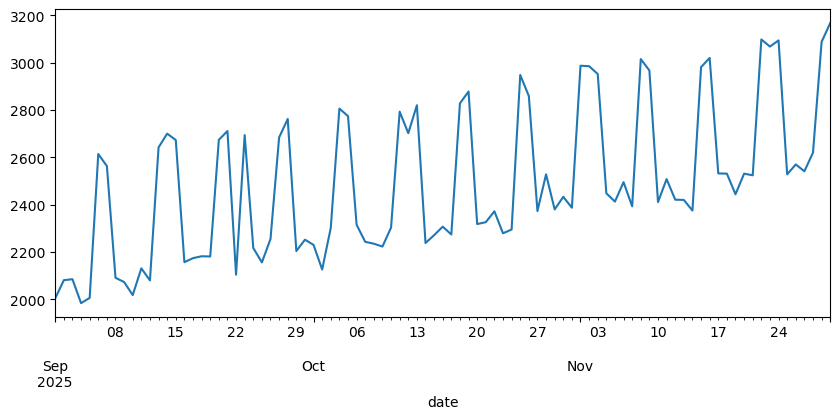

In [74]:
# 顧客数の日別推移
plt.figure(figsize=(10, 4))
df1.groupby('date')['customer_id'].count().plot(kind='line')  # countならこの方が楽
# df_count = df1.groupby("date")["customer_id"].count().reset_index(name="customer_count")
# sns.lineplot(data=df_count, x="date", y="customer_count")
plt.show()

# トレンドか周期性かはわからないがだんだんと増えている感じ

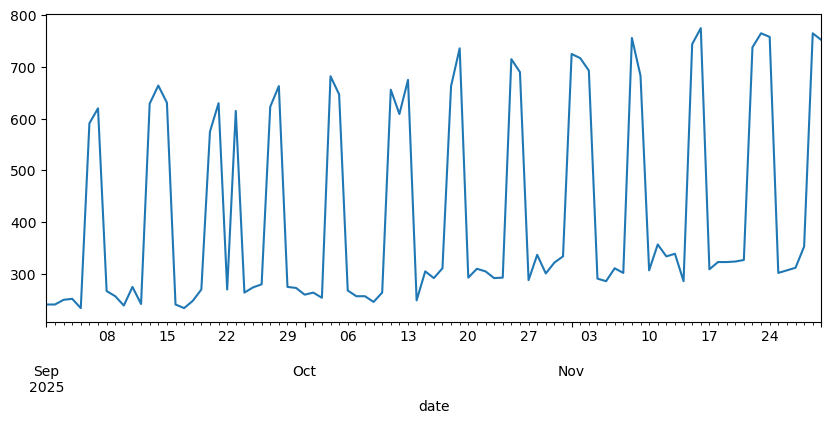

In [75]:
# 店舗数の日別推移
plt.figure(figsize=(10, 4))
df1.groupby('date')['store_id'].count().plot(kind='line')  # countならこの方が楽
# df_count = df1.groupby("date")["store_id"].count().reset_index(name="store_count")
# sns.lineplot(data=df_count, x="date", y="store_count")
plt.show()

# トレンドか周期性かはわからないがだんだんと増えている感じ
# 顧客数の推移の流れでやっているが、店舗数の推移に意味はあるかもだしないかも

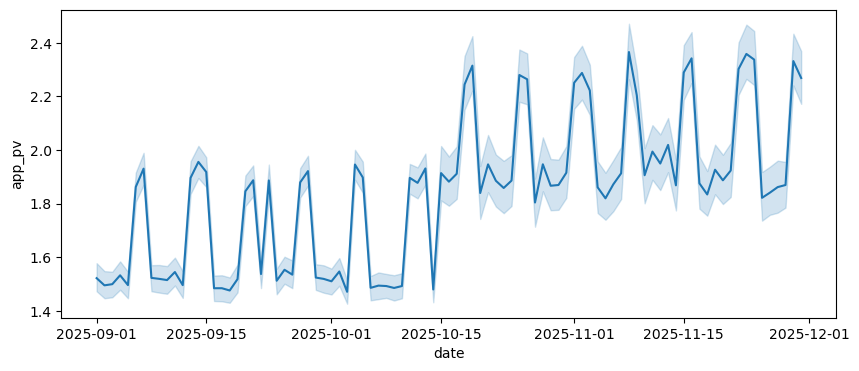

In [76]:
# app_pvの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['app_pv'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="app_pv", errorbar="ci")
plt.show()

# 周期性のようなものがありつつ、途中でガラッと傾向が変わっている（これはデータ生成ロジックに起因している）

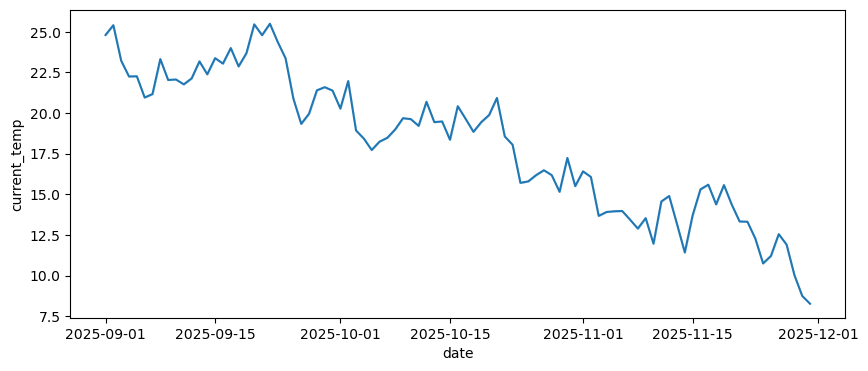

In [77]:
# 気温の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['current_temp'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="current_temp", errorbar="ci")
plt.show()

# だんだんと低下している（寒くなっている）
# errorbar="ci"指定しててもプロットされていない。このデータセットには同じdateが複数行あることはわかっていることから、同じdateであれば同じcurrent_tempらしい

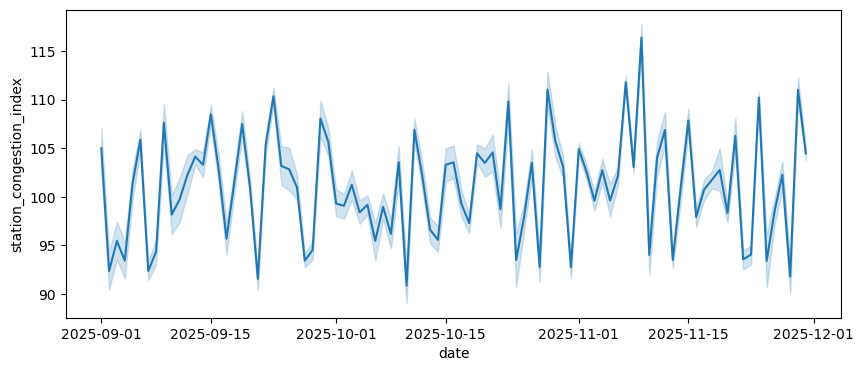

In [78]:
# station_congestion_indexの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['station_congestion_index'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="station_congestion_index", errorbar="ci")
plt.show()

# トレンドや周期性がありそうかはこれだけではわかりにくい
# ciがプロットされているので、同じdateであってもstation_congestion_indexは異なるらしい（store_idと連動してるため）

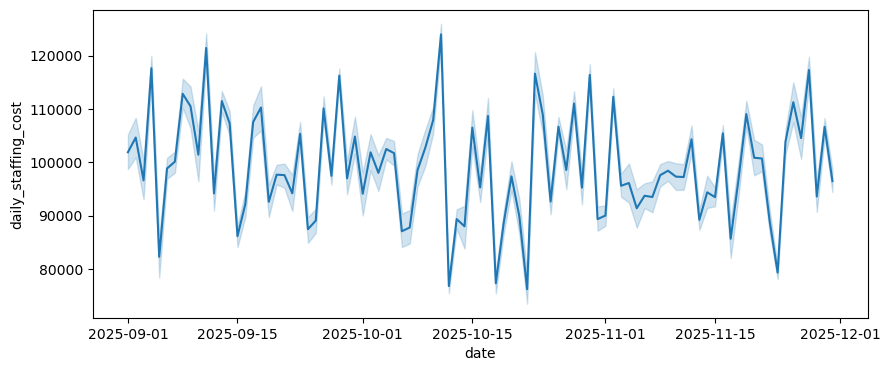

In [79]:
# daily_staffing_costの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['daily_staffing_cost'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="daily_staffing_cost", errorbar="ci")
plt.show()

# トレンドや周期性がありそうかはこれだけではわかりにくい
# ciがプロットされているので、同じdateであってもdaily_staffing_costは異なるらしい（store_idと連動してるため）

# EDA
目的変数を理解し、特徴量との関係性や、特徴量エンジニアリング目的で探索していく

- 目的変数の特徴: モデル良否の判断材料、予測の理由や根拠の理解、前処理の検討に活かす
  - 不均衡性: 大量データでもis_purchased=1（購入者）が少数になっていないか
  - 特徴量との相関: 特徴量の選択やモデル解釈に

- セグメントの違い: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）time series工程にて済み
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）

- 初手への対処策: 素早い初動回答を最優先するために、精度担保しつつデータ削減検討もしたい
  - 例えば10万件を（層別）ランダムサンプリングして、データセット全体の縮図として進める
  - 例えば直近3日間データだけ、例えば店舗Aだけにするなど、均一条件に統制して進める
  - これらをおこなうにはセグメント傾向を把握しておく必要ある

# Check y
目的変数の特徴をつかむ

- 不均衡チェック: 大量データでもis_purchased=1（購入者）が少数になっていないか
  1. ベースラインの把握: ラテ購入率（陽性率）の規模感次第でモデルでの改善目標も違ってくる
  1. 評価指標の判断: 購入率が極端に不均衡の場合はROC-AUCよりもPR-AUC
  1. 不均衡だった場合の対策検討: 前処理やモデルの学習方法
  1. 特徴量エンジニアリングの方向性把握: 購入率が極端に低い場合、平穏な特徴量だけではモデルが学習しきれないかも

- 特徴量との相関: 特徴量の選択やモデル解釈に
  - 目的変数と特徴量との相関をざっとみておく
  - 特徴量同士の相関もざっとみておく

In [80]:
# 目的変数（is_purchased）の内訳をみる

target = df1['is_purchased']

pd.DataFrame({
    'count': target.value_counts(dropna=False),
    'ratio(%)': target.value_counts(normalize=True, dropna=False) * 100
}).round(2)

# 目的変数（ラテ購入率）は観測データ全体のうち4%
# なのでこのデータセットにおける目的変数は、極端な不均衡データといえそう
# つまりROC-AUCよりもPR-AUCでモデル評価するのがよさそうだし、予測精度向上には強力な特徴量が欲しくなる

,count,ratio(%)
is_purchased,,
0,215402,95.12
1,11043,4.88


In [81]:
# 目的変数（is_purchased）を起点にして他の全カラムの有効データ件数をみる

# df1.groupby('is_purchased').count().T
df1.groupby('is_purchased').count().T.sort_values(0, ascending=True)
# df1.groupby('is_purchased').count().T.sort_values(1, ascending=True)

is_purchased,0,1
store_id,27264,11043
is_raining,27264,11043
station_congestion_index,27264,11043
daily_staffing_cost,27264,11043
current_temp,208959,10693
app_pv,213246,10935
membership_days,213688,10949
date,215402,11043
customer_id,215402,11043
is_visited,215402,11043


- 上の4つ、'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'
  - is_purchased, is_visitedが0だとnullらしいことが前の工程(null or not)でみえていた。
  - is_purchasedの大半は0とわかっているので、0のときにこれらの件数が極端に少ない（nullが多い）のは納得
- 続く2つ、'current_temp', 'app_pv'
  - null出現に規則性なさそうなことが前の工程(null or not)でみえていた
  - またnullの占める割合が少ないこともわかっていたので、0のときに件数が以降と同程度なのは納得
- 'membership_days'は数値型に混入物があり、混入物はnull置換した。そのぶんで後のカラムより件数少ないと思われる
- dateとis_purchasedの関係性はすでにみた
- 最後の3つ、day_of_week_num, is_weekend, is_holidayは追加した特徴量たち、かつis_purchasedの関係性はすでにみた

探索にあたって  
- 時点データ以外に目的変数との関連性ありそうに思えるカラムは
  - is_purchasedとの関係性をまだみていないことやカラム名称からして、store_id, customer_id, is_visitedが候補
  - お店あるいは顧客に紐付くこれら特徴量を目的変数の視点で眺めてみる

In [82]:
# 目的変数（is_purchased）とis_visitedの関係性
# 2値変数同士なのでクロス集計する

pd.crosstab(df1['is_purchased'], df1['is_visited'])

# is_visited=0のときは必ずis_purchased=0らしい
# 来店してないなら購入してない状態にあるというのは自然

is_visited,0,1
is_purchased,,
0,188138,27264
1,0,11043


In [83]:
# 目的変数（is_purchased）の内訳をみる（来店者ベース）

target = df1.query('is_visited == 1')['is_purchased']

pd.DataFrame({
    'count': target.value_counts(),
    'ratio(%)': target.value_counts(normalize=True) * 100
}).round(2)

# 目的変数（ラテ購入率）は観測データ全体のうち4%と極端な不均衡データだった
# 来店有無で区分すると、来店者の購入率は3割弱、極端に不均衡というわけでもなさそう

# 来店する前段階ではラテの購入確率は4%だったのが、来店したら購入確率が30%近くまで上がるのは、（当たり前ではあるが）来店してしまえばラテの購入確率は急上昇するとも言える

,count,ratio(%)
is_purchased,,
0,27264,71.17
1,11043,28.83


**方針検討**
- 購入有無(y: is_purchased)と来店有無(is_visited)には強い関係性がある。
- であれば、目的変数は以下2つに分解して捉えるとよさそう。
  - 来店するかどうか要因: どうやって店舗に足を運んでもらえるか（来店有無という行動履歴以外に、曜日、天気、気温など）
  - 来店したうえで購入するかどうか要因: 顧客自身の特性（購入意欲のようなもの、よくラテを飲む、ラテが好きかなど）
- P(購入)= P(来店) × P(購入∣来店) 
  - P(来店) ＝ ログが存在する日に来店する確率（is_visited=1の行数 / データセット全体の行数）
  - P(購入∣来店) ＝ 来店という条件のもとで、購入する確率（分母はis_visited=1の行数）
  - モデルで予測したい「未来のある日の購入確率」は、2つの確率の掛け算（条件付き確率）
- 前者については、is_visitedを筆頭にすでにいくつかの特徴量がある。
- 後者について、顧客ごとの特性を表す特徴量を追加することで、予測に有用な情報を加えられる可能性がある。

であれば、後者の特徴量は、is_visited=1をベースにした指標が適していそう。
- is_visited=0コミだと購入率4%と不均衡なため、来店有無による顧客の違いが、顧客ごとの特性を表す指標に反映されにくくなる。
- 例えば過去の購入率を特徴量とする場合、来店しなかった日も分母に含めると、購入率は全体として低い値に寄りやすい。
- そこで、来店した日を分母とした過去の購入率であれば、「来店したときに購入しやすいか」という**顧客特性をより直接的に**表現できる。
- このように、予測したい事象に対応した指標を特徴量として作成することで、モデルが利用しやすい情報になることが期待できる。

ちなみに、
- データセット全体では is_purchased=1（陽性率）は4%と不均衡で、かつ is_visited=0 のときは必ず is_purchased=0 となる。
- そのため、is_visitedをそのまま特徴量に入れると、モデルは「is_visited=0 なら is_purchased=0」という関係を強く利用する可能性がある。
- これは期待しているモデルではない。それに当日の来店有無で予測するのは目的変数をカンニングしてる状態でもある。
- いずれにしろ、is_visitedは特徴量として使えない。

**対処案**
1. 来店者のみでモデル作成する
    - is_visited=1のデータだけでモデルを作成する
    - シンプルでわかりやすい、素早く実行しやすい、ビジネス目的にも一致しており理解も得やすい（制御しにくい来店させるためのアクションは留保のうえ、来店した場合の分類予測に特化しやすい）
1. 2段階モデルを組む
    - 1段階目: 全ユーザーを対象に来店予測モデルAを作成、2段階目: 来店した場合の購入予測モデルBを作成する
    - 最終的な予測値（最終スコア）は、モデルAの予測確率 × モデルBの予測確率］ という掛け算で算出する。
    - 来店するかどうか含めて全ユーザーの購入確率を予測したい場合に適している。
    - 各モデルがそれぞれのタスクに集中できる一方、モデルが2つになるため、構築・評価・運用はより複雑になる。
1. 当日のis_visitedを「過去の行動履歴」に置き換える
    - 例えば過去にたくさん来店している人は購入しやすそう、などの発想からis_visitedに代わる特徴量を用意する。
    - 例えば過去一定期間の来店日数、来店率、購入日数、購入率など
    - 時点データならではの特徴を活かしつつ、当日来店してない→当日購入はしない、という因果を打ち消せる。
    - この場合、1同様に来店者のみモデルとすることもできるし、全ユーザー対象のモデルとすることもできる。
    - 後者の場合は購入率4%という極端な不均衡の影響を考慮する必要があり、モデルの評価や特徴量設計が難しくなる可能性がある。

**方針**
- 来店者のみでモデル作成する
- is_visitedは使わない（使えない）
- 過去の行動履歴をもとに、特徴量を新規作成、追加する

## is_visited

In [84]:
# is_visitedを起点にして他の全カラムの有効データ件数をみる
df1.groupby('is_visited').count().T.sort_values(0, ascending=True)

# is_visited=0のときは店舗関連のカラムはnullになっている

is_visited,0,1
store_id,0,38307
is_raining,0,38307
station_congestion_index,0,38307
daily_staffing_cost,0,38307
current_temp,182502,37150
app_pv,186264,37917
membership_days,186647,37990
date,188138,38307
customer_id,188138,38307
is_purchased,188138,38307


## by store_id

In [85]:
# 目的変数（is_purchased）とstore_idの関係性

print(df1['is_purchased'].mean().round(4))  # 購入率の全体平均
print(df1.query('is_visited==1')['is_purchased'].mean().round(4))  # 来店者のみでの購入率

# 店舗ごとの購入率（店舗格差があるか？）
# print(df1.groupby('store_id')['is_purchased'].mean().sort_values(ascending=False).round(4))
print(df1.groupby('store_id')['is_purchased'].mean().sort_index().round(4))

# is_visited=0ならstore_idはnullのため、store_id別の購入率は来店ベースの集計値になっている

0.0488
0.2883
store_id
Store_A    0.2785
Store_B    0.2376
Store_C    0.2763
Store_D    0.2666
Store_E    0.2811
Store_F    0.3877
Store_G    0.3716
Store_H    0.2537
Store_I    0.2124
Store_J    0.3093
Name: is_purchased, dtype: float64


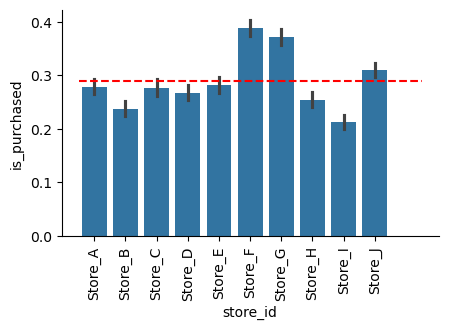

In [86]:
# グラフで確認してみる
sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3)
plt.hlines(df1.query('is_visited==1')['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['store_id'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
plt.xticks(rotation=90)
plt.show()

# 店舗によって、来店ベースの購入率には差がありそう（store_idは特徴量として役立ちそう）

# Segment store
- 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）
- 店舗別の購入率についてはcheck y工程ですでに見ているので他の特徴量について
- EDAは特徴量エンジニアリング目的なのと、store_id自体が特徴量として役立ちそうなことはわかっているので、興味本位で深入りしすぎない

In [87]:
# null check工程でis_purchased, is_visited（0/1の2値）が0だとstore_idはnullになるとわかっている
# なので以下はcountにしても出力値は同じだし、meanだと全部1になる（store_idがnullでなければ必ずis_visited=1のデータになってる） 
df1.groupby('store_id')['is_visited'].sum().round(3)
# df1.groupby('store_id')['is_visited'].mean().round(3)

# 店によって来店数が極端に違うということはなさそう

store_id
Store_A    3723
Store_B    3762
Store_C    3656
Store_D    3586
Store_E    3867
Store_F    4111
Store_G    3714
Store_H    3803
Store_I    3927
Store_J    4158
Name: is_visited, dtype: int64

In [88]:
# 数値型カラムについて、店舗(store_id)ごとの平均値をみる

df1.groupby('store_id').mean(numeric_only=True)

,membership_days,app_pv,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost,day_of_week_num,is_weekend,is_holiday
store_id,,,,,,,,,,,
Store_A,353.461205,5.242342,1.0,0.278539,17.678652,0.219447,100.333105,91937.223476,3.509535,0.452592,0.109589
Store_B,370.077605,5.436344,1.0,0.237640,17.674092,0.169059,99.372804,97068.547581,3.579479,0.471823,0.108187
Store_C,361.557947,5.091664,1.0,0.276258,17.688976,0.206783,98.240394,98613.234683,3.560722,0.470186,0.110503
Store_D,363.897782,5.126796,1.0,0.266592,17.648384,0.256832,101.558633,99690.154769,3.472672,0.457334,0.117959
Store_E,376.369984,5.273250,1.0,0.281096,17.624815,0.173261,102.133701,98442.457461,3.532454,0.468580,0.115335
Store_F,354.835205,5.410723,1.0,0.387740,17.497454,0.145950,104.741198,100218.004865,3.529798,0.464607,0.108489
Store_G,359.380060,5.152427,1.0,0.371567,17.763447,0.116586,103.046927,100161.344911,3.525310,0.458805,0.109047
Store_H,365.081232,5.300772,1.0,0.253747,17.626436,0.239022,100.375298,96525.313437,3.544833,0.465685,0.105180
Store_I,349.970490,5.245035,1.0,0.212376,17.659320,0.231729,102.584804,100818.348612,3.604533,0.477464,0.100076


In [89]:
# 気になるもの（平均値が大きく違いそうなもの）があれば、さらに詳しくみる

df1.groupby('store_id')['current_temp'].describe().round(3)

# ほぼ同じ。time series工程で同じdateは同じcurrent_tempらしいことが見えていたが、store_idによってcurrent_tempが違うということはないのかもしれない

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,3607.0,17.679,4.328,8.264,13.955,18.357,21.167,25.498
Store_B,3635.0,17.674,4.366,8.264,13.910,18.239,21.167,25.498
Store_C,3545.0,17.689,4.391,8.264,13.910,18.357,21.167,25.498
Store_D,3488.0,17.648,4.437,8.264,13.910,18.298,21.167,25.498
Store_E,3761.0,17.625,4.390,8.264,13.707,18.357,21.167,25.498
Store_F,3985.0,17.497,4.353,8.264,13.707,18.049,20.958,25.498
Store_G,3612.0,17.763,4.381,8.264,13.955,18.430,21.167,25.498
Store_H,3688.0,17.626,4.452,8.264,13.910,18.430,21.167,25.498
Store_I,3808.0,17.659,4.388,8.264,13.910,18.357,21.167,25.498


In [90]:
df1.pivot_table(index='date', columns='store_id', values='current_temp', aggfunc='mean')

# 同じdateであれば、store_idに関係なく同じcurrent_tempらしい

store_id,Store_A,Store_B,Store_C,Store_D,Store_E,Store_F,Store_G,Store_H,Store_I,Store_J
date,,,,,,,,,,
2025-09-01,24.804228,24.804228,24.804228,24.804228,24.804228,24.804228,24.804228,24.804228,24.804228,24.804228
2025-09-02,25.408087,25.408087,25.408087,25.408087,25.408087,25.408087,25.408087,25.408087,25.408087,25.408087
2025-09-03,23.221803,23.221803,23.221803,23.221803,23.221803,23.221803,23.221803,23.221803,23.221803,23.221803
2025-09-04,22.251496,22.251496,22.251496,22.251496,22.251496,22.251496,22.251496,22.251496,22.251496,22.251496
2025-09-05,22.264802,22.264802,22.264802,22.264802,22.264802,22.264802,22.264802,22.264802,22.264802,22.264802
...,...,...,...,...,...,...,...,...,...,...
2025-11-26,12.546724,12.546724,12.546724,12.546724,12.546724,12.546724,12.546724,12.546724,12.546724,12.546724
2025-11-27,11.904238,11.904238,11.904238,11.904238,11.904238,11.904238,11.904238,11.904238,11.904238,11.904238
2025-11-28,10.026783,10.026783,10.026783,10.026783,10.026783,10.026783,10.026783,10.026783,10.026783,10.026783


# Segment Customer
- 本分析のテーマ（顧客単位での分類予測）とも関係深いため、入念にみていく
- データセット自体のドメイン知識は乏しくとも、時点データの特性やマーケティング観点（例えばRFM: Recency, Frequency, Monetaryなど）を糸口に探索するとよさそう


## grand total
1. Total（全体）
    - 全期間計での累積集計値
    - 顧客の「ベースライン」やポテンシャルを把握（Heavy/Medium/Light, 既存/復活/新規）
    - 例: 期間計でのapp_pv発生日数を顧客単位で集計

EDAや特徴量作成の対象となるカラム
- 顧客の行動履歴データ: is_visited（来店有無） is_purchased（購入有無） app_pv（アプリ閲覧数）
- 顧客のマスターデータ: membership_days（アプリ会員になってからの経過日数）
- 四則演算可能な数値型カラム: current_temp, is_raining, station_congestion_index, daily_staffing_cost

In [91]:
# まずはEDAから（特徴量作成はのちほど）
# 常連さんと一見さんがいるのか

# 期間計での出現回数（app_pv発生日数）を顧客単位でカウント
print(df1[["customer_id"]].value_counts(ascending=False).head())
print(df1["customer_id"].value_counts(ascending=True).head())

# いるらしい

customer_id
eqh7iw8g       75
356f9bg3       72
wb8nbspy       72
t2ne0d2c       71
l354ebga       71
Name: count, dtype: int64
customer_id
v2bhn7mj    1
yro5f87e    1
ss752u8e    1
ml0he932    1
ku4oqyx9    1
Name: count, dtype: int64


In [92]:
# 顧客単位で集約したDataFrameを作る

# app_pv以外のis_visitedやis_purchasedについても顧客特性の違い（常連さんか一見さんか）を把握する意図
df_user = df1.groupby('customer_id').agg(
    total_count=('customer_id', 'count'),  # その人の出現回数（全ログ行数、app_pv発生日数）
    visit=('is_visited', 'sum'),  # 来店日数
    purchase=('is_purchased', 'sum')  # 購入日数
).reset_index()

# 期間計での来店率と購入率（来店ベース）を計算
df_user['visit_rate'] = (df_user['visit'] / df_user['total_count'])
df_user['purchase_rate'] = (df_user['purchase'] / df_user['visit']).fillna(0)  # 来店日数が0の人は購入率を0にする
"""
- 購入率の分母は来店率の分母にそろえたくなるが、total_countという同じ情報が両方に入ってしまう（特徴量同士の相関が強くなってマルチコっぽい感じになってしまう）
- 購入率の分母を来店日数にすることで、来店率=足を運ぶ動機（例えばapp_pvが誘発する来店意欲とか）と、来店ベース購入率=来店時の財布の紐の緩さ（購入意欲のようなものとか）と、それぞれの特徴量が「異なる要素の顧客特性」を表現しやすくなる
"""

df_user.head()

,customer_id,total_count,visit,purchase,visit_rate,purchase_rate
0,002ec2m6,22,2,2,0.090909,1.000000
1,002ic2u8,15,1,1,0.066667,1.000000
2,004lflnv,53,7,6,0.132075,0.857143
3,007u3616,26,0,0,0.000000,0.000000
4,0089km8u,20,2,0,0.100000,0.000000


In [93]:
df_user[['total_count', 'visit', 'purchase', 'visit_rate', 'purchase_rate']].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)

# 1人あたりのapp_pv発生日数は平均22日、来店日数4日、購入日数1日、来店率0.17、（来店ベース）購入率0.27

,total_count,visit,purchase,visit_rate,purchase_rate
count,9994.0000,9994.0000,9994.0000,9994.0000,9994.0000
mean,22.6581,3.8330,1.1050,0.1675,0.2594
std,12.6227,3.1027,1.6325,0.1009,0.3178
min,1.0000,0.0000,0.0000,0.0000,0.0000
1%,5.0000,0.0000,0.0000,0.0000,0.0000
5%,9.0000,0.0000,0.0000,0.0000,0.0000
10%,10.0000,1.0000,0.0000,0.0526,0.0000
25%,14.0000,2.0000,0.0000,0.1000,0.0000
50%,19.0000,3.0000,1.0000,0.1556,0.1429
75%,29.0000,5.0000,2.0000,0.2222,0.5000


In [94]:
# 出現回数を適度に区分して、来店率や購入率との関係性をみる

# 機械的に4等分（quantile）してみる
df_user['total_count_freq'] = pd.qcut(df_user['total_count'], q=4, labels=['1_Light', '2_Medium-low', '3_Medium-high', '4_Heavy'])

res = df_user.drop(columns=["customer_id"]).groupby("total_count_freq", observed=False).mean().round(2)
# 対象カラム自体の件数(行数)をsize()でcountしてデータフレームの先頭に差し込む
res.insert(0, "count", df_user.groupby(df_user['total_count_freq']).size())
res

# 出現回数が多いほど、来店日数や購入日数は多い。来店率や購入率は大差ないようにも増加するようにも思える

,count,total_count,visit,purchase,visit_rate,purchase_rate
total_count_freq,,,,,,
1_Light,2990,10.98,1.74,0.49,0.16,0.23
2_Medium-low,2245,16.82,2.83,0.82,0.17,0.27
3_Medium-high,2363,23.83,4.22,1.15,0.18,0.26
4_Heavy,2396,41.54,7.00,2.11,0.17,0.28


In [95]:
# 出現回数をキリの良い数字で区切るなら
def get_freq_tier(count):
    if 1 <= count <= 10:
        return '1_Light(1-10)'
    elif 11 <= count <= 20:
        return '2_Medium-low(11-20)'
    elif 21 <= count <= 30:
        return '3_Medium-high(21-30)'
    else:
        return '4_Heavy(31+)'

# total_countに適用
df_user['total_count_freq'] = df_user['total_count'].apply(get_freq_tier)

# 上と同じ
res = df_user.drop(columns=["customer_id"]).groupby("total_count_freq", observed=False).mean().round(2)
res.insert(0, "count", df_user.groupby(df_user['total_count_freq']).size())
res

# quantileと刻みがあまり変わってないもあり、大きな違いはなさそう（というか判断しにくい）

,count,total_count,visit,purchase,visit_rate,purchase_rate
total_count_freq,,,,,,
1_Light(1-10),1080,8.10,1.25,0.37,0.16,0.22
2_Medium-low(11-20),4510,15.29,2.54,0.71,0.17,0.25
3_Medium-high(21-30),2158,24.89,4.41,1.21,0.18,0.26
4_Heavy(31+),2246,42.31,7.12,2.14,0.17,0.28


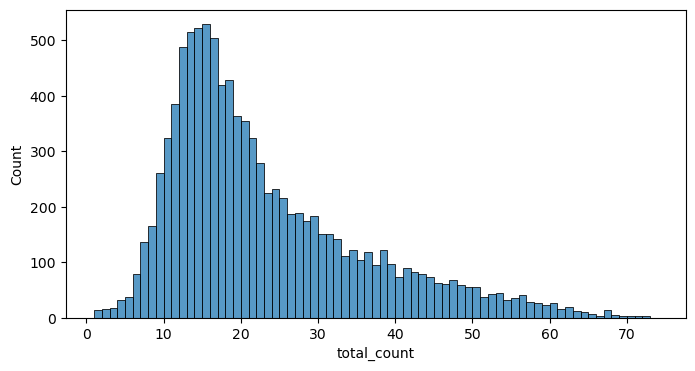

In [96]:
# 顧客別出現回数のhistogramをプロット
# 出現回数の（ある意味）恣意的な区分では、来店率や購入率の傾向を見誤る可能性が残ることから、ちょっと立ち戻って分布の形状をみておく

plt.figure(figsize=(8, 4))
# 出現回数は離散値のため、binsの数値指定次第ではギザギザなhistogramになる場合があることからrange指定する
# sns.histplot(data=df_user, x='total_count', bins=range(1, customer_counts.max()), kde=True, stat="density")
sns.histplot(data=df_user, x='total_count', bins=range(1, df_user['total_count'].max()), kde=False)

# plt.title("顧客別アプリログ出現回数の分布（ヒストグラム × KDE）")
# plt.xlabel("出現回数（91日間のログ行数）")
# plt.ylabel("密度（Density）")
# plt.xlabel('Number of Occurrences per Customer')
# plt.ylabel('Number of Customers')
# plt.title('Distribution of Customer Occurrences')

plt.show()

# 最頻値は左側に寄っていて裾が長い分布らしい（app_pv発生日数はロングテール）

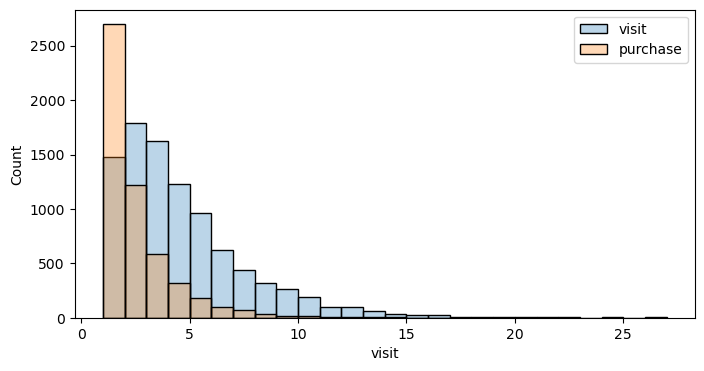

In [97]:
# 顧客別来店日数、購入日数のhistogramをプロット

plt.figure(figsize=(8, 4))
sns.histplot(data=df_user, x='visit', bins=range(1, df_user['visit'].max()), kde=False, alpha=0.3, label='visit')
sns.histplot(data=df_user, x='purchase', bins=range(1, df_user['purchase'].max()), kde=False, alpha=0.3, label='purchase')
plt.legend()
plt.show()

# 出現回数同様に、最頻値は左側に寄っていて裾が長い分布らしい

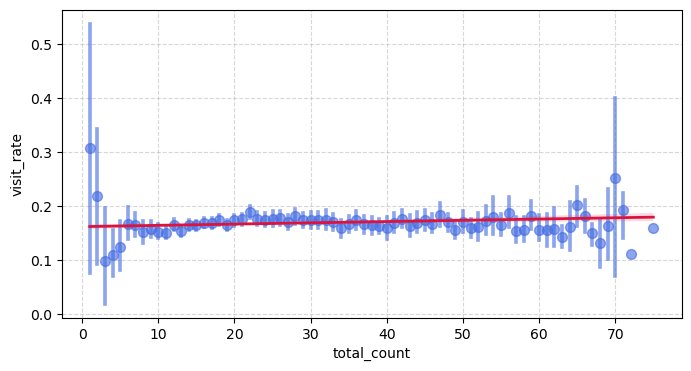

In [98]:
# 出現回数別の期間内来店率をプロット

plt.figure(figsize=(8, 4))
# 横軸: 出現回数、縦軸: 出現回数別の平均来店率
sns.regplot(data=df_user, x='total_count', y='visit_rate',
    x_estimator=np.mean,   # x軸の値ごとにyの平均値をプロットするように指定
    # order=2,  # 多項式回帰を指定して非線形なトレンドを見ることもできる（未指定時は線形近似直線が描画される）
    scatter_kws={"color": "royalblue", "alpha": 0.6},
    line_kws={"color": "crimson", "linewidth": 2}
)
# x_estimator=np.meanを指定しないと、x軸の値ごとにyの平均値ではなく、ユーザー単位のvisit_rateがプロットされる。来店率は左端（出現回数1回）では0/1の値をとる。平均的な来店率が0に近い場合、右にいくほど来店率が低い方のプロットが多くなり、なにか意味ありげなプロットに見えてしまう
plt.grid(True, linestyle='dashed', alpha=0.5)
plt.show()

# 左端ではバラツキが大きい（人数が少なく95%ciが広い）ながらも平均来店率はやや高め、右端でもバラツキが大きい（人数少ないため）ながらも平均来店率が少々高い場合もあるか（出現回数が多い人ほど、期間内来店率が低い傾向があるように見える）
# 近似直線(赤線)はほぼ横向き、気持ち右肩上がりか。つまり1人あたりの期間内来店率は出現回数によらず大局的にはほぼ同程度。出現回数がすごく少ない場合とすごく多い場合には少々高めなのかもしれない

# ただしあくまで期間内計での来店率。ひょっとしたらその時々や状況に応じて違いはあるのかもしれない

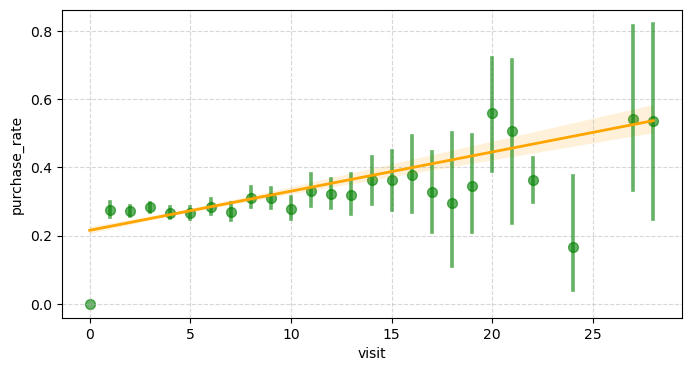

In [99]:
# 来店日数別の期間内購入率(来店ベース)をプロット

plt.figure(figsize=(8, 4))

# 横軸: 来店日数、縦軸: 来店日数別の平均購入率
sns.regplot(data=df_user, x='visit', y='purchase_rate',
    x_estimator=np.mean,   # x軸の値ごとにyの平均値をプロットするように指定
    # order=2,  # 多項式回帰を指定して非線形なトレンドを見ることもできる（未指定時は線形近似直線が描画される）
    scatter_kws={"color": "green", "alpha": 0.6},
    line_kws={"color": "orange", "linewidth": 2}
)
# x_estimator=np.meanを指定しないと、x軸の値ごとにyの平均値ではなく、ユーザー単位のpurchase_rateがプロットされる。購入率は左端（出現回数1回）では0/1の値をとる。平均的な購入率が0に近い場合、右にいくほど購入率が低い方のプロットが多くなり、なにか意味ありげなプロットに見えてしまう
plt.grid(True, linestyle='dashed', alpha=0.5)
plt.show()

# （右にいくほどバラツキ大きいが）来店日数が多いと、購入しやすいのかも
# ただし来店率同様にあくまで期間内計での集計値である。ひょっとしたらその時々や状況に応じて違いはあるのかもしれない

## rare customer
顧客の行動履歴データ
- is_visited（来店有無） is_purchased（購入有無） app_pv（アプリ閲覧数）
- ここまでの探索から、app_pvが発生した場合にその日のdateでログが生まれるっぽい

と書いていた。まさか行動履歴データが全部0のような人はいないよね？

In [100]:
# 顧客単位で期間計で集約して
customer_summary = df1.groupby('customer_id')[['app_pv', 'is_visited', 'is_purchased']].sum().reset_index()
customer_summary.head() 

,customer_id,app_pv,is_visited,is_purchased
0,002ec2m6,32.0,2,2
1,002ic2u8,19.0,1,1
2,004lflnv,79.0,7,6
3,007u3616,29.0,0,0
4,0089km8u,28.0,2,0


In [101]:
# 行動履歴データ3種すべて0の人のcustomer_idを取り出して
target_id = customer_summary.query('is_visited==0 & app_pv==0 & is_purchased==0')['customer_id']
print(len(target_id))  # 何人いるかな
df1.query("customer_id in @target_id")

# 1人出現した。dateは期間内の最終日2日前。
# app_pvがnullなのは、そういうデータも微量にあるとはわかっていた（なにかが理由でnullになったのだろうと捉えていた）。
# membership_daysが0ということはこの日にアプリ会員登録はした（この手続き自体はpvカウントの対象外）。
# app_pvは置いといて（0なのかnullかは不明）、残り2日のうちには来店も購入しなかったらしい。
# だが顧客masterには会員として登場するので、ここではデータとして登場したのだろう。
# （このデータセットではapp_pvのmin=1だったことからすると、この人のapp_pvは発生してたがなにかが理由でnullになったのでは）

# 休眠状態ともいえるこの顧客がモデルの学習に役立つかというとあまり意味はなさそう。
# だが1人だし影響軽微なので、レコード削除せずにこのままでもいいかも。

0


,date,customer_id,membership_days,app_pv,store_id,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost,day_of_week_num,is_weekend,is_holiday


# Add Customer Feature
- 過去の行動履歴をもとに、**顧客特性を表しそうな特徴量**を作成する
- 時系列データでの顧客特性を表す区分は主に5つの切り口が考えられる

1. Total（累積）
    - 期間計での累積（expanding）
    - 各顧客のベースラインやポテンシャルを把握（Heavy/Medium/Light, 既存/復活/新規）
    - 例: 期間計でのapp_pv発生日数を顧客単位で集計
2. State（状態）
    - 一定期間での推移（rolling）
    - 顧客状態の「緩やかな」変動を把握（そのときどきでのコンディションを中期的、連続的な視点で捉える）
    - 例: 前日までの直近7日間のapp_pvの移動平均
3. Lag（鮮度）
    - 直近の情報（lag）
    - 古い情報よりも「新鮮な」情報を重点的に把握（Recencyを点で捉える）
    - 例: 1日前や3日前のapp_pv
4. Momentum（勢い）
    - スパイク、変化の差分や比率（diff, ratio）
    - 顧客状態の「急激な」変化を把握（短期的、瞬発的な視点で捉える）
    - 例: 3日前のapp_pv - 7日前のapp_pv（差分あるいは割って比率にする。StateやLagから算出）
5. Interval（間隔）
   - 行動をしていない空白期間（interval）
   - 「定着度合い」や習慣、リズムを把握（Recencyを線で捉える）
   - 例: 最後のapp_pv発生日からの経過日数（短いほど定着してそう、間が空くほど離脱リスクありそう）

新規特徴量の候補となるカラム
- 顧客の行動履歴データ: app_pv（アプリ閲覧数） is_visited（来店有無） is_purchased（購入有無） 
- 顧客のマスターデータ: membership_days（アプリ会員になってからの経過日数）
- 四則演算可能な数値型カラム: current_temp, is_raining, station_congestion_index, daily_staffing_cost

新規特徴量作成時の注意点
- 「当日を含まない、未来をカンニングできない」前日までを対象とする。
- このデータセットの場合は時点が連続していない（日付が飛び飛びな）点を考慮しながら加工する。
- 割り算値の分母に注意。例えばここでは、購入率の分母は「来店ベース」にする（来店日数が0の人は購入率を0にする）。
- こうすることで、来店率=足を運ぶ動機と、購入率=来店時の財布の紐の緩さ（購入意欲のようなものとか）と、それぞれの特徴量が「異なる要素の顧客特性」を表現しやすくなる（来店率と購入率の情報が重複しすぎないようにする）。

In [102]:
# 累積や以降の特徴量作成をスムーズにおこなうため、「時点でソートした」dataframeを別途用意する
# 顧客単位でソートする必要はないが、実行結果が目視確認しやすいという点で安心安全
df_ts = df1.sort_values(by=['customer_id', 'date', 'store_id']).reset_index(drop=True)

df_ts.head()

,date,customer_id,membership_days,app_pv,store_id,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost,day_of_week_num,is_weekend,is_holiday
0,2025-09-01,002ec2m6,279.0,1.0,NaN,0,0,24.804228,NaN,NaN,NaN,0,0,0
1,2025-09-05,002ec2m6,283.0,1.0,NaN,0,0,22.264802,NaN,NaN,NaN,4,0,0
2,2025-09-09,002ec2m6,287.0,4.0,Store_I,1,1,22.034767,0.0,80.767376,128455.0,1,0,0
3,2025-09-18,002ec2m6,296.0,NaN,NaN,0,0,22.869419,NaN,NaN,NaN,3,0,0
4,2025-09-22,002ec2m6,300.0,1.0,NaN,0,0,25.498009,NaN,NaN,NaN,0,0,0


## Total（expanding）
- ここでは、app_pv, is_visited, is_purchasedを対象に「当日を含まない、未来をカンニングできない」前日までで作成。

In [103]:
# app_pvの総和: 顧客の熱量や濃密さのようなものを表す指標との位置付け
df_ts['expanding_pv_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['app_pv']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)

# app_pvの発生日数: 顧客の習慣性や粘着性のようなものを表す指標との位置付け
df_ts['expanding_pv_count'] = (
    df_ts.set_index('date').groupby('customer_id')['app_pv']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).count()).values
)

# 来店回数（日数）の総和: 0/1の2値で1の出現率が少ないためsumのみ
df_ts['expanding_visit_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['is_visited']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)

# 購入回数（日数）の総和: 0/1の2値で1の出現率が少ないためsumのみ
df_ts['expanding_purchase_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['is_purchased']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)


# expandingを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'expanding']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,expanding_pv_sum,expanding_pv_count,expanding_visit_sum,expanding_purchase_sum
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,NaN
1,2025-09-05,002ec2m6,1.0,NaN,0,0,1.0,1.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,2.0,2.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,6.0,3.0,1.0,1.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,6.0,3.0,1.0,1.0


In [104]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

# 抽出したいキーワードをリストにしておく
include_keywords = ['expanding']
target_col = [col for col in df_ts.columns if any(kw in col for kw in include_keywords)]

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 極端にnullが多かったり、不自然な（ありえない）代表値になってなければOK

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
expanding_pv_sum,float64,216451,216349,102,0.05,380,569.34
expanding_pv_count,float64,216451,216451,0,0.00,75,2886.01
expanding_visit_sum,float64,216451,216451,0,0.00,28,7730.39
expanding_purchase_sum,float64,216451,216451,0,0.00,23,9410.91


In [105]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値や0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['expanding_pv_sum'].describe().round(2))
print(df_ts.groupby('is_purchased')['expanding_pv_count'].describe().round(2))
print(df_ts.groupby('is_purchased')['expanding_visit_sum'].describe().round(2))
print(df_ts.groupby('is_purchased')['expanding_purchase_sum'].describe().round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                 count   mean    std  min   25%   50%   75%    max
is_purchased                                                      
0             205682.0  26.33  27.23  1.0   9.0  19.0  35.0  435.0
1              10667.0  37.36  49.13  1.0  10.0  22.0  43.5  446.0
                 count   mean    std  min  25%   50%   75%   max
is_purchased                                                    
0             215402.0  14.14  11.87  0.0  5.0  11.0  20.0  74.0
1              11043.0  15.42  12.65  0.0  6.0  12.0  22.0  70.0
                 count  mean   std  min  25%  50%  75%   max
is_purchased                                                
0             205778.0  2.44  2.55  0.0  1.0  2.0  4.0  27.0
1              10673.0  3.06  3.35  0.0  1.0  2.0  4.0  27.0
                 count  mean   std  min  25%  50%  75%   max
is_purchased                                                
0             205778.0  0.66  1.18  0.0  0.0  0.0  1.0  22.0
1              10673.0  1.30  1.94  0.0  0.0 

## State (rolling)
- ここでは、app_pv, is_visited, is_purchasedを対象に「当日を含まない、未来をカンニングできない」前日までで作成。
- rollingなどの特徴量を作る際にどう集約するか？
  - 基本はmeanが無難かも
  - nullが多かったり、2値のうちどちらかに偏ってるような場合は、sumの方が情報が濃くなるかも
  - マイルドな割合（mean）よりは、蓄積の方が目的変数との関係をうまく表現できそうならsumがいいかも
  - 足し算(sum)に意味がない尺度の場合はmean（気温のような比率尺度とか）
  - mean,sum以外の候補は、max,min,std
  - 迷うときや急ぐときは、ひとまずmeanもsumも作ってモデルに考えさせる（あとで考える）

In [106]:
# 過去hoge日間のローリングを算出する
# 直近1日間（前日）、3日間、5日間、7日間の、移動平均（来店日数、購入日数、来店率、購入率）など

"""
rollingを指定条件で計算して元のdataframeに代入するというわかりにくいコードの説明にゃん
- set_index('date'): dateをインデックスにして後続のウィンドウ'7D'を正しく機能させる（元のインデックスは変わらない）
- groupby: 以降集計値を切り分けたいセグメントの指定
- transform: SQLのOVER()に相当、元のdf_tsの行数そのままでウィンドウ関数の結果を代入する
  - lambda x: （groupbyで指定したグループごとに）データxに対して、以下を実行する関数の定義
  - rolling('7D': 7行ではなく7日間、すなわち現在の行（当日）から7日前までに収まる日付の行を対象に、
  - closed='left': ただし右端、つまり現在の行（当日）を含まないようにして、
  - min_periods=1: 7日分のデータがまるまるなくても、あるぶんのデータで、後続で指定する計算をおこなう
  - values: 計算結果の数字だけの配列を取り出して代入する（set_indexやgroupbyでのインデックスが残ってると元々のインデックスと一致しなくてpandasが迷子になる。transformは行数が合うようには機能するがインデックスの違いまでは対処しきれない）
- なぜ7日まで？データセットの期間が91日間で、モデル作成時にsplitすることを踏まえるとあまり長くはしにくいため
"""

# ループで指定期間のローリングを一気に作る
for d in [1, 3, 5, 7]:

    # app_pvのsum: 前日までの移動合計
    df_ts[f'rolling_pv_sum_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )

    # app_pvのmean: 前日までの移動平均
    df_ts[f'rolling_pv_mean_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).mean())
        .values
    )

    # app_pvのcount: app_pvの発生日数の移動平均行数
    # 来店率や購入率の分母に使う（countしてnullにならないカラムを使うこと。でないと、のちの割り算値がinfになったりする)
    df_ts[f'rolling_count_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).count())
        .values
    )

    # is_visitedのsum: 前日までの移動平均（2値なのでsumすればmeanになる）
    df_ts[f'rolling_visit_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_visited']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )

    # is_purchasedのsum: 前日までの移動平均（2値なのでsumすればmeanになる）
    df_ts[f'rolling_purchase_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )


# 割り算値の計算
# ループで指定期間のローリングを一気に作る
for d in [1, 3, 5, 7]:

    df_ts[f'rolling_visit_rate_{d}d'] = (
        (df_ts[f'rolling_visit_{d}d'] / df_ts[f'rolling_count_{d}d'])
        .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
        .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め
    )

    # 来店(1ならば)→購入(0/1)、来店0=購入0という構図がわかってるので、移動平均購入率の分母は来店ベースにする
    df_ts[f'rolling_purchase_rate_{d}d'] = (
        (df_ts[f'rolling_purchase_{d}d'] / df_ts[f'rolling_visit_{d}d'])
        .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
        .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め（is_visited=0の行では移動平均購入率は0になる）
    )


# rollingを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'rolling']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,rolling_pv_sum_1d,rolling_pv_mean_1d,rolling_count_1d,rolling_visit_1d,...,rolling_visit_7d,rolling_purchase_7d,rolling_visit_rate_1d,rolling_purchase_rate_1d,rolling_visit_rate_3d,rolling_purchase_rate_3d,rolling_visit_rate_5d,rolling_purchase_rate_5d,rolling_visit_rate_7d,rolling_purchase_rate_7d
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-09-05,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [107]:
# # 期待していた集計がちゃんとできてそうか（目視確認）

# # 先にcustomer_id単位で集約したdataframeからpurchase>0を1人指定
# target_id = df_user.query("purchase > 0")['customer_id'].iloc[0]

# # カラムが多いので見たいところだけを指定
# target_col = ['date', 'customer_id', 'rolling_count_7d', 'is_visited', 'rolling_visit_7d', 'rolling_visit_rate_7d', 'is_purchased', 'rolling_purchase_7d', 'rolling_purchase_rate_7d']

# # 指定分だけを表示
# # 日付が飛び飛びなので目視はちょっと大変。当日以降の未来をリークする集計値になっていないかをきっちり確認したいならやろうね
# df_ts[target_col].query("customer_id == @target_id").head(15)

In [108]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

# 抽出したいキーワードをリストにしておく
include_keywords = ['rolling']
target_col = [col for col in df_ts.columns if any(kw in col for kw in include_keywords)]

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 極端にnullが多かったり、不自然な（ありえない）代表値になってなければOK

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
rolling_pv_sum_1d,float64,216451,76379,140072,64.71,27,2828.85
rolling_pv_mean_1d,float64,216451,76379,140072,64.71,27,2828.85
rolling_count_1d,float64,216451,77134,139317,64.36,2,38567.00
rolling_visit_1d,float64,216451,77134,139317,64.36,2,38567.00
rolling_purchase_1d,float64,216451,77134,139317,64.36,2,38567.00
rolling_pv_sum_3d,float64,216451,144075,72376,33.44,57,2527.63
rolling_pv_mean_3d,float64,216451,144075,72376,33.44,83,1735.84
rolling_count_3d,float64,216451,144884,71567,33.06,4,36221.00
rolling_visit_3d,float64,216451,144884,71567,33.06,4,36221.00
rolling_purchase_3d,float64,216451,144884,71567,33.06,4,36221.00


In [109]:
# 新規作成した特徴量はモデルに役立ちそうか
# ここでは代表して7のをみてる

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値や0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['rolling_pv_sum_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_pv_mean_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_count_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_visit_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_purchase_7d'].describe().round(2))

print(df_ts.groupby('is_purchased')['rolling_visit_rate_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['rolling_purchase_rate_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                 count  mean    std  min  25%  50%  75%    max
is_purchased                                                  
0             181252.0  5.05   6.02  1.0  2.0  4.0  6.0  105.0
1               9474.0  7.81  11.52  1.0  2.0  4.0  8.0   98.0
                 count  mean   std  min  25%   50%  75%   max
is_purchased                                                 
0             181252.0  1.85  1.62  1.0  1.0  1.00  2.0  26.0
1               9474.0  2.60  2.97  1.0  1.0  1.33  2.5  22.0
                 count  mean   std  min  25%  50%  75%  max
is_purchased                                               
0             181763.0  2.66  1.52  0.0  1.0  2.0  4.0  7.0
1               9495.0  2.73  1.53  0.0  1.0  2.0  4.0  7.0
                 count  mean   std  min  25%  50%  75%  max
is_purchased                                               
0             181763.0  0.45  0.68  0.0  0.0  0.0  1.0  6.0
1               9495.0  0.56  0.80  0.0  0.0  0.0  1.0  6.0
                 cou

## new feature eda
- 新規作成した特徴量自体をEDAするなら
  - なんらかの顧客区分でセグメントしたり、時点推移を眺めたり、元の値と移動平均値を対比など

In [110]:
# # EDA: 例えば直近7日間のapp_pv発生日数で顧客を4区分して比較

# # app_pv発生日数で4区分してみる
# def get_freq_tier(count):
#     if count <= 1:
#         return '1_Light(1)'
#     elif 2 <= count <= 3:
#         return '2_Medium-low(2-3)'
#     elif 4 <= count <= 5:
#         return '3_Medium(4-5)'
#     else:
#         return '4_Heavy(6+)'
# # 直近7日間のapp_pv発生日数に適用
# df_ts['rolling_count_7d_freq'] = df_ts['rolling_count_7d'].apply(get_freq_tier)

# # 集計対象のカラムを指定してセグメント別にmeanを計算
# # 'rolling_purchase_rate_7d'があるので来店ベースで集計するのがいいかもね
# res = df_ts.groupby("rolling_count_7d_freq", observed=False)[['rolling_count_7d', 'rolling_visit_7d', 'rolling_purchase_7d', 'rolling_visit_rate_7d', 'rolling_purchase_rate_7d']].mean().round(2)
# res.insert(0, "count", df_ts.groupby(df_ts['rolling_count_7d_freq']).size())
# res

In [111]:
# # EDA: 例えば直近7日間の来店日数で顧客を4区分して比較

# # 来店日数で4区分してみる
# def get_freq_tier(count):
#     if count <= 0:
#         return '1_Non(0)'
#     elif 1 <= count <= 1:
#         return '2_Light(1)'
#     elif 2 <= count <= 2:
#         return '3_Medium(2)'
#     else:
#         return '4_Heavy(3+)'

# # 直近7日間の来店日数に適用
# df_ts['rolling_visit_7d_freq'] = df_ts['rolling_visit_7d'].apply(get_freq_tier)

# # 集計対象のカラムを指定してセグメント別にmeanを計算
# # 'rolling_purchase_rate_7d'があるので来店ベースで集計するのがいいかもね
# res = df_ts.groupby("rolling_visit_7d_freq", observed=False)[['rolling_visit_7d', 'rolling_purchase_7d', 'rolling_purchase_rate_7d']].mean().round(2)
# res.insert(0, "count", df_ts.groupby(df_ts['rolling_visit_7d_freq']).size())
# res

In [112]:
# # EDA: 例えば直近7日間来店日数、購入日数の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts, x="date", y="rolling_visit_7d", errorbar="ci", label='rolling_visit_7d')
# sns.lineplot(data=df_ts, x="date", y="rolling_purchase_7d", errorbar="ci", label='rolling_purchase_7d')
# plt.ylabel('Days per Weekly')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

In [113]:
# # EDA: 例えば直近7日間来店率の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts, x="date", y="is_visited", errorbar="ci", label='is_visited')
# sns.lineplot(data=df_ts, x="date", y="rolling_visit_rate_7d", errorbar="ci", label='rolling_visit_rate_7d')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

In [114]:
# # EDA: 直近7日間購入率（来店ベース）の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts.query("is_visited == 1"), x="date", y="is_purchased", errorbar="ci", label='is_purchased(is_visited=1)')
# sns.lineplot(data=df_ts.query("is_visited == 1"), x="date", y="rolling_purchase_rate_7d", errorbar="ci", label='rolling_purchase_rate_7d(is_visited=1)')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

## Lag

In [115]:
# ラグを算出する
# 1日前、3日前、5日前、7日前
# hoge日前に来店（購入）した人は、本日も来店（購入）しやすいのでは仮説に基づく
# lagの1dはrollingの1dと同じ値になるので片方は不要なんだが、ひとまず作ってしまう（のちほど削除する）

# ループで指定日数のラグを一気に作る
for d in [1, 3, 5, 7]:

    # 日付が飛び飛びなのでrollingのときと同じ手順で実行する
    df_ts[f'lag_pv_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'lag_visit_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_visited']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'lag_purchase_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )


# lagを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'lag']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].tail()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,lag_pv_1d,lag_visit_1d,lag_purchase_1d,lag_pv_3d,lag_visit_3d,lag_purchase_3d,lag_pv_5d,lag_visit_5d,lag_purchase_5d,lag_pv_7d,lag_visit_7d,lag_purchase_7d
226440,2025-11-20,zzy6ci30,2.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226441,2025-11-26,zzy6ci30,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
226442,2025-11-27,zzy6ci30,1.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0
226443,2025-11-28,zzy6ci30,1.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226444,2025-11-30,zzy6ci30,1.0,NaN,0,0,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
# # 期待していた集計がちゃんとできてそうか（目視確認）

# # 先にcustomer_id単位で集約したdataframeからpurchase>0を1人指定
# target_id = df_user.query("purchase > 0")['customer_id'].iloc[0]

# # カラムが多いので見たいところだけを指定
# target_col = ['date', 'customer_id', 'is_visited', 'lag_visit_1d', 'lag_visit_3d', 'lag_visit_5d', 'lag_visit_7d', 'is_purchased', 'lag_purchase_1d', 'lag_purchase_3d', 'lag_purchase_5d', 'lag_purchase_7d']

# # 指定分だけを表示
# # 日付が飛び飛びなので目視はちょっと大変。きっちり確認したいならやろうね
# df_ts[target_col].query("customer_id == @target_id").head(15)

In [117]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

# 抽出したいキーワードをリストにしておく
include_keywords = ['lag']
target_col = [col for col in df_ts.columns if any(kw in col for kw in include_keywords)]

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 日付が飛び飛びなのもあってlag特徴量はnullが多い

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
lag_pv_7d,float64,216451,70637,145814,67.37,29,2435.76
lag_visit_7d,float64,216451,71351,145100,67.04,2,35675.50
lag_purchase_7d,float64,216451,71351,145100,67.04,2,35675.50
lag_pv_5d,float64,216451,71588,144863,66.93,28,2556.71
lag_visit_5d,float64,216451,72294,144157,66.60,2,36147.00
lag_purchase_5d,float64,216451,72294,144157,66.60,2,36147.00
lag_pv_3d,float64,216451,72682,143769,66.42,28,2595.79
lag_visit_3d,float64,216451,73401,143050,66.09,2,36700.50
lag_purchase_3d,float64,216451,73401,143050,66.09,2,36700.50
lag_pv_1d,float64,216451,76379,140072,64.71,27,2828.85


In [118]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['lag_pv_1d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_pv_3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_pv_5d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_pv_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                count  mean   std  min  25%  50%  75%  90%   95%   99%   max
is_purchased                                                                
0             72445.0  1.90  2.19  1.0  1.0  1.0  2.0  4.0   5.0  14.0  28.0
1              3934.0  2.98  4.18  1.0  1.0  1.0  4.0  6.0  15.0  20.0  28.0
                count  mean   std  min  25%  50%  75%  90%   95%   99%   max
is_purchased                                                                
0             69023.0  1.90  2.21  1.0  1.0  1.0  2.0  4.0   5.0  14.0  28.0
1              3659.0  2.77  3.85  1.0  1.0  1.0  3.0  6.0  14.0  19.0  25.0
                count  mean   std  min  25%  50%  75%  90%   95%   99%   max
is_purchased                                                                
0             67911.0  1.90  2.21  1.0  1.0  1.0  2.0  4.0   5.0  14.0  28.0
1              3677.0  2.78  3.84  1.0  1.0  1.0  3.0  5.0  14.0  19.0  25.0
                count  mean   std  min  25%  50%  75%  90%    95%   99%   ma

In [119]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
print(df_ts.groupby('is_purchased')['lag_visit_1d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_visit_3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_visit_5d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['lag_visit_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

# 来店率のlagは、目的変数にはあまり関係ないのかも
# lagの日数でもあまり違いはなさそう（lag7はやや多めだが週の周期性の上乗せぶんかも）

                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             73163.0  0.17  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3971.0  0.21  0.41  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             69706.0  0.17  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3695.0  0.18  0.38  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             68584.0  0.17  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3710.0  0.19  0.40  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                          

In [120]:
print(df_ts.query('is_visited==1').groupby('is_purchased')['lag_purchase_1d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['lag_purchase_3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['lag_purchase_5d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['lag_purchase_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 購入率のlagは、目的変数には来店率lagよりかは役に立つのかも
# lagの日数でもあまり違いはなさそう（lag7はやや多めだが週の周期性の上乗せぶんかも）

               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             9274.0  0.05  0.21  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3971.0  0.10  0.30  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             8704.0  0.05  0.21  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3695.0  0.07  0.25  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             8711.0  0.05  0.21  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3710.0  0.09  0.28  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                       

In [121]:
# 昨日来店者は本日も来店しやすい？

print(df_ts['is_visited'].mean().round(2))  # 全体ベース
# hoge日前来店者の本日来店率平均
print(df_ts.query("lag_visit_1d == 1")['is_visited'].mean().round(2))  # 昨日来店者のみ
print(df_ts.query("lag_visit_3d == 1")['is_visited'].mean().round(2))
print(df_ts.query("lag_visit_5d == 1")['is_visited'].mean().round(2))
print(df_ts.query("lag_visit_7d == 1")['is_visited'].mean().round(2))

# 昨日来店者は本日も来店しやすいということはなさそう（本日来店0.17→昨日来店者ベース0.2）

0.17
0.2
0.18
0.19
0.21


In [122]:
# 昨日購入者は本日も購入しやすい？

print(df_ts.query("is_visited==1")['is_purchased'].mean().round(2))  # 本日来店ベース
# hoge日前購入者の本日来店ベースでの購入率平均
print(df_ts.query("is_visited==1 & lag_purchase_1d == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & lag_purchase_3d == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & lag_purchase_5d == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & lag_purchase_7d == 1")['is_purchased'].mean().round(2))

# 昨日購入者は本日も購入しやすいらしい（本日来店ベース0.29→本日来店かつ昨日購入者ベース0.4）
# 3日前、5日前、7日前（週の周期性の上乗せぶんかも）も同様。直近の購入者は本日も購入しやすい。例えば常連客やラテ大好きな人なのかも
# 本件の場合はサンプルデータの生成ロジックにおける各顧客固有のbase_latte_preferenceの設定値に起因する
# この直接的には観測困難な変数を、購入意欲や好みを表す特徴量として扱うのはごく自然

0.29
0.48
0.38
0.44
0.54


## Momentum （diff, ratio）
- 変化の差分や比率は、前述のState（rolling）やLagから計算可能。
- ただしこのデータセットでは、時点が連続していない（日付が飛び飛びな）のと、来店や購入は1の出現率が少ないため、Lagはnullが多い。
- つまり、LagからMomentumを作るとnullや0が多くなってしまう。
- なのでここでは、State(rolling)をもとにして、変化の差分や比率を作成する。これにより、nullや0を減らせる。
- 一方で、rollingでスムージング（ダウンサンプリング）しているぶん、マイルドな値になる可能性あり。

In [123]:
# モメンタム（差分や比率）を、ローリングから算出する
# 直近1日間（前日）を起点に、直近3日/5日/7日間との、差分と比率
# 3と5や3と7などの差分、比率についてはモデルにまかせる（作成した特徴量の組み合わせから作ってもらう）

# 作成する特徴量のベース名を定義
# 日にちの数字が入る直前までの文字列をリスト化
base_features = [
    'pv_sum',
    'pv_mean',
    'count',
    'visit',
    'purchase',
    'visit_rate',
    'purchase_rate',
]

# 直近1日間と、3日・5日・7日間を比較
for target_d in [3, 5, 7]:

    for feature in base_features:

        # 比較するローリング特徴量
        col_1d = f'rolling_{feature}_1d'
        col_target = f'rolling_{feature}_{target_d}d'

        # 差分（1日 - 〇日）の作成
        df_ts[f'diff_{feature}_1to{target_d}d'] = (
            df_ts[col_1d] - df_ts[col_target]
        )

        # 比率（1日 / 〇日）の作成
        df_ts[f'ratio_{feature}_1to{target_d}d'] = (
            (df_ts[col_1d] / df_ts[col_target])
            .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
            .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め
        )


# diffまたはratioを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'diff', 'ratio']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,diff_pv_sum_1to3d,ratio_pv_sum_1to3d,diff_pv_mean_1to3d,ratio_pv_mean_1to3d,...,diff_count_1to7d,ratio_count_1to7d,diff_visit_1to7d,ratio_visit_1to7d,diff_purchase_1to7d,ratio_purchase_1to7d,diff_visit_rate_1to7d,ratio_visit_rate_1to7d,diff_purchase_rate_1to7d,ratio_purchase_rate_1to7d
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
1,2025-09-05,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0


In [124]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

# 抽出したいキーワードをリストにしておく
keywords = ['diff', 'ratio']
target_col = [col for col in df_ts.columns if any(kw in col for kw in keywords)]

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 極端にnullが多かったり、不自然な（ありえない）代表値になってなければOK

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
diff_pv_sum_1to3d,float64,216451,76379,140072,64.71,42,1818.55
diff_pv_sum_1to5d,float64,216451,76379,140072,64.71,68,1123.22
diff_pv_mean_1to3d,float64,216451,76379,140072,64.71,164,465.73
diff_pv_sum_1to7d,float64,216451,76379,140072,64.71,90,848.66
diff_pv_mean_1to7d,float64,216451,76379,140072,64.71,586,130.34
diff_pv_mean_1to5d,float64,216451,76379,140072,64.71,349,218.85
diff_purchase_1to5d,float64,216451,77134,139317,64.36,5,15426.80
diff_visit_1to5d,float64,216451,77134,139317,64.36,5,15426.80
diff_count_1to5d,float64,216451,77134,139317,64.36,5,15426.80
diff_count_1to7d,float64,216451,77134,139317,64.36,7,11019.14


In [125]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['diff_pv_sum_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_pv_mean_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_count_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_visit_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_purchase_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

print(df_ts.groupby('is_purchased')['diff_visit_rate_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['diff_purchase_rate_1to3d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))


# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                count  mean   std   min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                              
0             72445.0 -1.62  2.78 -44.0 -2.0 -1.0  0.0  0.0  0.0  0.0  0.0
1              3934.0 -2.51  4.79 -38.0 -2.0 -1.0  0.0  0.0  0.0  0.0  0.0
                count  mean   std    min  25%  50%  75%   90%   95%   99%  \
is_purchased                                                                
0             72445.0  0.01  1.07 -12.67  0.0  0.0  0.0  0.67  1.67  2.67   
1              3934.0  0.11  1.78 -10.00  0.0  0.0  0.0  1.50  2.33  7.50   

                max  
is_purchased         
0             13.67  
1             13.33  
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             73163.0 -0.84  0.75 -2.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0
1              3971.0 -0.86  0.76 -2.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0
       

In [126]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['diff_pv_sum_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_pv_mean_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_count_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_visit_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['diff_purchase_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

print(df_ts.groupby('is_purchased')['diff_visit_rate_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['diff_purchase_rate_1to7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))


# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                count  mean    std   min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                               
0             72445.0 -4.73   6.14 -94.0 -6.0 -3.0 -1.0  0.0  0.0  0.0  0.0
1              3934.0 -7.62  11.22 -82.0 -8.0 -4.0 -2.0  0.0  0.0  0.0  0.0
                count  mean   std   min  25%  50%  75%   90%  95%   99%   max
is_purchased                                                                 
0             72445.0  0.01  1.42 -12.5 -0.5  0.0  0.0  1.67  2.4  4.00  19.0
1              3934.0  0.15  2.36 -12.0 -0.6  0.0  0.0  2.25  4.0  9.23  21.2
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             73163.0 -2.44  1.60 -6.0 -4.0 -2.0 -1.0  0.0  0.0  0.0  0.0
1              3971.0 -2.52  1.59 -6.0 -4.0 -2.0 -1.0  0.0  0.0  0.0  0.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased  

## Interval
行動をしていない空白期間を算出する = 「最後に行動してから何日経過したか」を算出する

In [127]:
# インターバルを算出する

# どのカラムを集計対象とするか、作成する特徴量名、「行動あり」と判定する条件を指定する
interval_targets = [
    ('app_pv', 'app_pv', lambda x: x >= 1),  # pvが1以上なら行動あり
    ('is_visited', 'visit', lambda x: x == 1),  # 来店=1なら行動あり
    ('is_purchased', 'purchase', lambda x: x == 1),  # 購入=1なら行動あり
    # ('app_pv', 'app_pv', lambda x: x >= 5),  # 例えばpvが5以上なら行動あり
    # ('app_pv', 'app_pv', lambda x: x.notna()),  # 例えばpvがnullでなければ行動あり
]

# 指定分についてループ処理で一気につくる
for org_col, name, condition_func in interval_targets:

    # 行動ありの日を判定（conditionはTrue / Falseの配列になる）
    condition = condition_func(df_ts[org_col])

    # 行動が発生した日だけ日付を残す。指定カラムで条件を満たさないところ（conditionがFalseのとき）はNaTにする
    df_ts['_temp_action_date'] = df_ts['date'].where(
        condition, pd.NaT)  # NaT: Not a Timeの略。datetime型における「値がない」を表す。

    # 顧客ごとに、当日より前の最後の行動日（直前の行動日）を取得
    df_ts['_last_action_date'] = (
        df_ts
        .groupby('customer_id')['_temp_action_date']
        .transform(lambda x: x.shift(1).ffill())
        # 顧客ごとに、前回の行動日をshift(1)して（1行めのNaNは据え置き）
        # そして前方穴埋め（ffill: Forward Fill） 上の行（過去）から順に下方向（未来）にデータを見ていって、次に有効な値が登場するまでは直前の有効値を引き継ぐ（NaTを最終行動発生日に上書きするイメージ）
    )

    # 前回の行動からの経過日数を計算して、日数（整数）に変換
    new_col_name = f'interval_since_last_{name}'

    df_ts[new_col_name] = (
        df_ts['date'] - df_ts['_last_action_date']
    ).dt.days

# 使い終わった一時的な列を削除
df_ts = df_ts.drop(
    columns=['_temp_action_date', '_last_action_date']
)


# intervalを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'interval']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN
1,2025-09-05,002ec2m6,1.0,NaN,0,0,4.0,NaN,NaN
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,4.0,NaN,NaN
3,2025-09-18,002ec2m6,NaN,NaN,0,0,9.0,9.0,9.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,13.0,13.0,13.0


In [128]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

# 抽出したいキーワードをリストにしておく
keywords = ['interval']
target_col = [col for col in df_ts.columns if any(kw in col for kw in keywords)]

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 極端にnullが多かったり、不自然な（ありえない）代表値になってなければOK

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
interval_since_last_purchase,float64,216451,83119,133332,61.60,90,923.54
interval_since_last_visit,float64,216451,166994,49457,22.85,89,1876.34
interval_since_last_app_pv,float64,216451,216349,102,0.05,56,3863.38


In [129]:
check_null_and_uniques(df_ts.query('is_visited==1').groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
interval_since_last_purchase,float64,29022,15261,13761,47.42,88,173.42
interval_since_last_app_pv,float64,29022,29018,4,0.01,40,725.45
interval_since_last_visit,float64,29022,29022,0,0.00,86,337.47


In [130]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データだと見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['interval_since_last_app_pv'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['interval_since_last_visit'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['interval_since_last_purchase'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                 count  mean   std  min  25%  50%  75%  90%   95%   99%   max
is_purchased                                                                 
0             205682.0  3.68  4.02  1.0  1.0  2.0  5.0  8.0  12.0  20.0  63.0
1              10667.0  3.56  3.84  1.0  1.0  2.0  4.0  8.0  11.0  19.0  51.0
                 count   mean   std  min  25%   50%   75%   90%   95%   99%  \
is_purchased                                                                  
0             158504.0  14.40  14.0  1.0  4.0  10.0  20.0  34.0  44.0  64.0   
1               8490.0  13.29  13.4  1.0  4.0   9.0  18.0  32.0  42.0  62.0   

               max  
is_purchased        
0             89.0  
1             86.0  
                count   mean    std  min  25%   50%   75%   90%   95%   99%  \
is_purchased                                                                  
0             77337.0  21.99  18.62  1.0  7.0  17.0  33.0  50.0  61.0  76.0   
1              5782.0  18.39  16.97  1.0  6.0  13.

In [131]:
# 明らかに意味が同じ特徴量は、片方を削除する
# 後続の特徴量間の相関係数やモデルの予測結果などから不要と判断した特徴量の削除は、mergeした後の工程でやるほうがわかりやすそう

# rollingの1dとlagの1dは同じなので、後者を削除する
include_keywords = ['lag', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)  # 指定キーワードの「すべて」がカラム名に含まれている場合
]

df_ts = df_ts.drop(columns=target_cols)

In [132]:
# rolling_pv_sum_1dとrolling_pv_mean_1dは同じなので、後者を削除する
include_keywords = ['rolling_pv_mean', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)


# rolling_visit_1dとrolling_visit_rate_1dは同じなので、後者を削除する
include_keywords = ['rolling_visit_rate', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)


# rolling_purchase_1dとrolling_purchase_rate_1dは同じなので、後者を削除する
include_keywords = ['rolling_purchase_rate', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)

# Merge Features
元のdataframeに、expanding, rolling, lagなど新規作成した特徴量を突合する

In [133]:
# 新規作成した特徴量（元のdataframeに存在しないもの）
new_features = [
    col for col in df_ts.columns
    if col not in df1.columns
]

# 元のdataframeに、必要なカラムだけをmergeしたdf作成
df = pd.merge(df1, df_ts[['customer_id', 'date'] + new_features], 
              on=['customer_id', 'date'], how='left')

# 大量にmergeした直後で、一度データフレームをコピーしてメモリをきれいに並び替える（デフラグ）
df = df.copy()

## Drop Features
不要と判断した特徴量などを削除する

In [134]:
# 来店者のみでモデル作成する方針なので、ここで絞り込んでおく
df = df.query('is_visited == 1').reset_index(drop=True)

# 当日の行動履歴は、当日購入有無のカンニングになってしまうので削除しておく
# dateはsplitで使うのでまだ残しておく（customer_idもまだ残しておいたほうが中身確認しやすい）
df = df.drop(columns=['app_pv', 'is_visited'])


# モデルの予測結果などから不要と判断した特徴量があれば、ここで削除する（必要に応じて適宜追加してもよい）

# カラム名指定で削除する場合（例えば制御不能な特徴量や、不要と判断した特徴量など）
df = df.drop(columns=['is_raining', 'current_temp', 'station_congestion_index', 'daily_staffing_cost'])

# キーワードを指定して削除する場合
exclude_keywords = []  # とりあえず空の状態でも実行可能
exclude_keywords = ['ratio']  # 例えば、(G)PFIやSHAPなどから不要と判断した特徴量など

exclude_cols = [
    col for col in df.columns
    if any(kw in col for kw in exclude_keywords)  # 指定キーワードの「いずれか」がカラム名に含まれている場合 
]

df = df.drop(columns=exclude_cols)

## Corr

In [135]:
# 目的変数と特徴量（数値型カラムのみ）との相関係数を見ておく
corr = df.corr(numeric_only=True)['is_purchased']

corr_report = pd.DataFrame({'corr': corr, 'abs_corr': corr.abs()})  # 生の相関係数と、絶対値を計算
corr_report.sort_values(by='abs_corr', ascending=False).round(4).head(20)  # corr絶対値の大きい順で並び替えて表示

# 「目的変数と単純な関係がありそうか」「変な強い関係がないか」を見ておくことで、以下を企図している
# 1. ここまでのデータ加工に間違いがないか？
#   ・極端に相関強い特徴量が出現する → この特徴量、目的変数とほぼ同じ情報なのでは？
#   ・想定していた特徴量が出現しない → 特徴量を作る処理が変なのでは？
# 2. ターゲットとの関係をざっくり把握する
#   ・この特徴量は目的変数と正の関係がありそうだなくらいの探索的な情報にはなる
# 3. 「危ない特徴量」を発見する
#   ・特に相関が異常に高い特徴量は、リーケージやターゲットの直接的なコピー、代理変数になっていないか確認すべし。
#   ・ただし相関が低いから不要とは限らない

,corr,abs_corr
is_purchased,1.0000,1.0000
expanding_purchase_sum,0.2123,0.2123
lag_purchase_7d,0.1463,0.1463
rolling_purchase_7d,0.1331,0.1331
lag_pv_7d,0.1315,0.1315
diff_purchase_1to7d,-0.1276,0.1276
rolling_pv_sum_1d,0.1226,0.1226
is_weekend,0.1196,0.1196
rolling_purchase_rate_7d,0.1151,0.1151
rolling_pv_mean_7d,0.1151,0.1151


In [136]:
# 特徴量同士（数値型カラムのみ）の相関係数を見ておく

# この関数は後工程でも使う
def get_top_correlations(df, target_cols=None, threshold=0.7, top_n=30):    
    if target_cols is not None:
        features = df.drop(columns=target_cols)  # 目的変数を指定した場合のみ除外
    else:
        features = df

    corr_matrix = features.corr(numeric_only=True)  # 相関行列の計算

    # 重複を避けるため上三角行列のみ取得（対角成分も除外）
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # 縦持ちに変換してNaNを除外
    corr_series = upper_tri.stack().reset_index()
    corr_series.columns = ['feature_1', 'feature_2', 'correlation']

    # 絶対値でソート用カラムを追加し、しきい値以上をフィルタリング
    corr_series['abs_corr'] = corr_series['correlation'].abs()

    high_corr_df = corr_series[
        corr_series['abs_corr'] >= threshold
    ]

    # 絶対値順にソートして指定件数を返す
    return (high_corr_df.sort_values(by='abs_corr', ascending=False).drop(columns=['abs_corr']).head(top_n).reset_index(drop=True))

In [137]:
# 特徴量同士（数値型カラムのみ）の相関係数を見ておく
target_cols = ['is_purchased']  # 目的変数は除外する
top_corr_df = get_top_correlations(df, target_cols=target_cols, threshold=0.7, top_n=20)
print(top_corr_df)

# 「特徴量同士で重複・冗長なものがないか」を見ておくことで、以下を企図している
# ・完全に重複している特徴量を整理する
# ・ほぼ同じ情報を持つ特徴量が大量に生成されていないか確認する
# ・特徴量エンジニアリングの結果が想定どおりか確認する
# ・ただし「高相関だから削除」は必須ではない

              feature_1                 feature_2  correlation
0      rolling_count_7d          diff_count_1to7d    -0.998325
1      rolling_count_5d          diff_count_1to5d    -0.996991
2      rolling_count_3d          diff_count_1to3d    -0.992423
3     rolling_pv_sum_7d         diff_pv_sum_1to7d    -0.969320
4   rolling_purchase_3d  rolling_purchase_rate_3d     0.957723
5    rolling_pv_mean_5d        rolling_pv_mean_7d     0.945951
6     rolling_pv_sum_5d         diff_pv_sum_1to5d    -0.944646
7     rolling_pv_sum_5d         rolling_pv_sum_7d     0.940538
8   rolling_purchase_5d  rolling_purchase_rate_5d     0.924400
9    rolling_pv_mean_3d        rolling_pv_mean_5d     0.922556
10    diff_pv_sum_1to5d         diff_pv_sum_1to7d     0.920712
11   diff_pv_mean_1to5d        diff_pv_mean_1to7d     0.919026
12    rolling_pv_sum_5d         diff_pv_sum_1to7d    -0.899446
13    rolling_pv_sum_3d         rolling_pv_sum_5d     0.898592
14     diff_count_1to5d          diff_count_1to7d     0

## Sort, Cast

In [138]:
# 時点データをきちんとsplitできるようにソートしておく
# （この後の工程では日付でsplitしてるのでソート必須ではないが、しておくに越したことはない）

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
df = df.sort_values(by=['date', 'store_id']).reset_index(drop=True)

In [139]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出る場合がある

float_cols = df.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df[float_cols] = df[float_cols].astype(float)

In [140]:
# カラム数やカラム名を確認
print(f"Number of columns: {len(df.columns.to_list())}")
df.columns

Number of columns: 70


Index(['date', 'customer_id', 'membership_days', 'store_id', 'is_purchased',
       'day_of_week_num', 'is_weekend', 'is_holiday', 'expanding_pv_sum',
       'expanding_pv_count', 'expanding_visit_sum', 'expanding_purchase_sum',
       'rolling_pv_sum_1d', 'rolling_count_1d', 'rolling_visit_1d',
       'rolling_purchase_1d', 'rolling_pv_sum_3d', 'rolling_pv_mean_3d',
       'rolling_count_3d', 'rolling_visit_3d', 'rolling_purchase_3d',
       'rolling_pv_sum_5d', 'rolling_pv_mean_5d', 'rolling_count_5d',
       'rolling_visit_5d', 'rolling_purchase_5d', 'rolling_pv_sum_7d',
       'rolling_pv_mean_7d', 'rolling_count_7d', 'rolling_visit_7d',
       'rolling_purchase_7d', 'rolling_visit_rate_3d',
       'rolling_purchase_rate_3d', 'rolling_visit_rate_5d',
       'rolling_purchase_rate_5d', 'rolling_visit_rate_7d',
       'rolling_purchase_rate_7d', 'lag_pv_3d', 'lag_visit_3d',
       'lag_purchase_3d', 'lag_pv_5d', 'lag_visit_5d', 'lag_purchase_5d',
       'lag_pv_7d', 'lag_visit_7d', '

In [141]:
df.head()

,date,customer_id,membership_days,store_id,is_purchased,day_of_week_num,is_weekend,is_holiday,expanding_pv_sum,expanding_pv_count,...,diff_pv_sum_1to7d,diff_pv_mean_1to7d,diff_count_1to7d,diff_visit_1to7d,diff_purchase_1to7d,diff_visit_rate_1to7d,diff_purchase_rate_1to7d,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase
0,2025-09-01,v8xz4wb6,393.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
1,2025-09-01,73x1cjf7,519.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
2,2025-09-01,ba70f0p8,109.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,2025-09-01,ms6csgoy,48.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
4,2025-09-01,v8f14heq,44.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
